In [ ]:
# ============================================================
# CELL 1. 기본 라이브러리 및 데이터 로드
# - 엑셀 데이터 로드
# - 전체 크기, 컬럼, 앞부분 확인
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

DATA_PATH = "/home/campus4d006/mldl_project/(iM뱅크) 2026 교육용 법인 익명데이터.xlsx"

df = pd.read_excel(DATA_PATH, engine="openpyxl")

# ------------------------------------------------------------
# 원본 컬럼 목록 저장
# - 이후 기준년월_p, _year, *_num 같은 보조 컬럼이 생겨도
#   피처 원천 컬럼에는 원본 데이터 컬럼만 사용하기 위함
# ------------------------------------------------------------

original_columns = df.columns.tolist()

print("원본 컬럼 수:", len(original_columns))
print("데이터 크기:", df.shape)

display(df.head())

display(pd.DataFrame({
    "컬럼명": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "결측치수": df.isna().sum().values,
    "결측률(%)": (df.isna().mean() * 100).round(2).values,
    "unique수": df.nunique(dropna=True).values
}))

원본 컬럼 수: 70
데이터 크기: (365988, 70)


,기준년월,법인ID,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,운전_할인어음잔액,운전_당좌대출잔액,운전_일반자금대출잔액,운전_무역금융잔액,운전_주택자금대출잔액,운전_기업구매자금대출잔액,운전_외상매출채권담보대출잔액,운전_기타운전자금대출잔액,여신_시설자금대출잔액,시설_일반자금대출잔액,시설_에너지절약시설대출잔액,시설_주택자금대출잔액,시설_기타시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,운전_할인어음좌수,운전_당좌대출좌수,운전_일반자금대출좌수,운전_무역금융좌수,운전_주택자금대출좌수,운전_기업구매자금대출좌수,운전_외상매출채권담보대출좌수,운전_기타운전자금대출좌수,여신_시설자금대출좌수,시설_일반자금대출좌수,시설_에너지절약시설대출좌수,시설_주택자금대출좌수,시설_기타시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수
0,202301,c665c79135345c7be173ebcc61465fe0bde03d935a1ce590a296b3564191e9d5,제조업,섬유제품 제조업; 의복제외,대구,대구광역시,최우수,Y,9.20,0.0,0.0,0.0,310.0,310.0,0.0,1200.0,0.0,0.0,1000.0,200.0,0,0.0,0.0,0.0,18.0,0.0,0.0,0,18.0,0.0,0.0,0.0,0.0,1200.0,280.0,0.0,0.0,3.50,740.0,1300.0,1600.0,5개초과 10개이하,0개,0개,0개,1개,1개,5개초과 10개이하,0개,0개,2개초과 5개이하,2개초과 5개이하,0개,0개,0개,0개,2개,0개,1개,0개,1개,10개초과 20개이하,0건,0건,40건초과 50건이하,50건 초과,0건,0건,2건초과 5건이하,40건초과 50건이하
1,202301,f23f02d337472145be9201d56547d33721c76ec63c5efd2e155343467bbdeec0,부동산업,부동산업,대구,대구광역시,일반,N,0.11,0.0,0.0,0.0,0.0,0.0,100.0,91.0,0.0,0.0,91.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,5.2,1.2,0.0,0.00,6.2,12.0,15.0,2개,0개,0개,0개,0개,0개,1개,0개,0개,1개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,2개,0건,0건,0건,5건초과 10건이하,1건,0건,0건,10건초과 20건이하
2,202301,4da4658f20a49e7ca3872154f20cf20631aa1d7cf6b0d471bfde6ccf55c9db06,도매 및 소매업,도매 및 상품 중개업,대구,대구광역시,우수,Y,38.00,0.0,200.0,0.0,0.0,0.0,1000.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,2100.0,1100.0,17.0,81.0,0.28,130.0,2700.0,2700.0,2개,0개,1개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,2개,0건,0건,20건초과 30건이하,40건초과 50건이하,2건초과 5건이하,1건,1건,5건초과 10건이하
3,202301,28577c48cf53b16d34a9eea1681d4e5d7c032c8877442f4da5e1f77faa9952bb,운수 및 창고업,육상운송 및 파이프라인 운송업,경북,경상북도,최우수,Y,9.90,0.0,0.0,0.0,0.0,0.0,0.0,300.0,0.0,0.0,300.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,310.0,0.0,0.0,0.00,6.3,300.0,310.0,5개초과 10개이하,0개,0개,0개,0개,0개,5개초과 10개이하,0개,0개,2개초과 5개이하,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,20개초과 30개이하,0건,0건,0건,50건 초과,0건,0건,0건,20건초과 30건이하
4,202301,6aacfadd304370c1bb04e298c12076a58892c77f7d19c359a8539d2dccfadc7b,교육 서비스업,교육 서비스업,대구,대구광역시,최우수,Y,20.00,2500.0,0.0,0.0,4100.0,0.0,136000.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1100.0,56.0,20.0,3.0,1.60,96.0,230.0,1200.0,2개,5개초과 10개이하,0개,0개,2개초과 5개이하,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,0개,5개초과 10개이하,0건,0건,5건초과 10건이하,20건초과 30건이하,10건초과 20건이하,2건,2건초과 5건이하,30건초과 40건이하


,컬럼명,dtype,결측치수,결측률(%),unique수
0,기준년월,int64,0,0.00,36
1,법인ID,object,0,0.00,15473
2,업종_대분류,object,0,0.00,18
3,업종_중분류,object,0,0.00,61
4,사업장_시도,object,12424,3.39,5
5,사업장_시군구,object,12424,3.39,13
6,법인_고객등급,object,0,0.00,3
7,전담고객여부,object,0,0.00,2
8,요구불예금잔액,float64,0,0.00,562
9,거치식예금잔액,float64,0,0.00,479


In [2]:
import matplotlib.font_manager as fm

fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
[k for k in fonts if "Nanum" in k or "나눔" in k][:30]

['NanumBarunGothic',
 'NanumGothic',
 'NanumGothicCoding',
 'NanumMyeongjo',
 'NanumSquare',
 'NanumSquareRound']

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# seaborn theme 먼저 설정
sns.set_theme(style="whitegrid")

# 그 다음 한글 폰트 강제 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False

print("현재 font.family:", plt.rcParams["font.family"])

현재 font.family: ['NanumGothic']


In [4]:
# ============================================================
# STEP 0. 기본 설정
# - 협업필터링 추천을 위해 법인ID, 기준년월, 상품 좌수/개수 컬럼을 사용
# - 좌수/개수 > 0이면 해당 상품을 보유한 것으로 정의
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

id_col = "법인ID"
date_col = "기준년월"

df_cf = df.copy()

# 기준년월을 월 단위 Period로 변환
df_cf["기준년월_p"] = (
    df_cf[date_col]
    .astype(str)
    .str.replace("-", "", regex=False)
    .str.replace(".", "", regex=False)
    .str[:6]
)

df_cf["기준년월_p"] = pd.PeriodIndex(
    pd.to_datetime(df_cf["기준년월_p"], format="%Y%m"),
    freq="M"
)

df_cf = df_cf.sort_values([id_col, "기준년월_p"]).reset_index(drop=True)

print("전체 행 수:", len(df_cf))
print("전체 법인 수:", df_cf[id_col].nunique())
print("전체 기간:", df_cf["기준년월_p"].min(), "~", df_cf["기준년월_p"].max())

전체 행 수: 365988
전체 법인 수: 15473
전체 기간: 2023-01 ~ 2025-12


In [5]:
# ============================================================
# STEP 1. 추천에 사용할 상품군 정의
# - 세부 상품명이 없기 때문에 상품군 단위로 추천
# - 좌수/개수 컬럼이 있는 상품만 우선 사용
# - 좌수/개수 > 0이면 보유, 0이면 미보유로 정의
# ============================================================

product_col_map = {
    "요구불예금": "요구불예금좌수",
    "거치식예금": "거치식예금좌수",
    "적립식예금": "적립식예금좌수",
    "수익증권": "수익증권좌수",
    "신탁": "신탁좌수",
    "퇴직연금": "퇴직연금좌수",
    "운전자금대출": "여신_운전자금대출좌수",
    "시설자금대출": "여신_시설자금대출좌수",
    "신용카드": "신용카드개수"
}

# 실제 데이터에 존재하는 컬럼만 사용
product_col_map = {
    product: col
    for product, col in product_col_map.items()
    if col in df_cf.columns
}

print("사용 상품군 수:", len(product_col_map))
print(product_col_map)

사용 상품군 수: 9
{'요구불예금': '요구불예금좌수', '거치식예금': '거치식예금좌수', '적립식예금': '적립식예금좌수', '수익증권': '수익증권좌수', '신탁': '신탁좌수', '퇴직연금': '퇴직연금좌수', '운전자금대출': '여신_운전자금대출좌수', '시설자금대출': '여신_시설자금대출좌수', '신용카드': '신용카드개수'}


In [6]:
# ============================================================
# STEP 2. 좌수/개수 컬럼을 숫자로 변환
# - 데이터가 '0개', '1개', '2개초과 5개이하' 같은 구간형 문자열일 수 있음
# - 협업필터링에서는 보유 여부만 필요하므로 숫자로 변환 후 0 초과 여부 사용
# ============================================================

def product_count_to_num(s):
    # 이미 숫자형이면 그대로 사용
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce").fillna(0)

    # 구간형 문자열 매핑
    count_map = {
        "0개": 0,
        "1개": 1,
        "2개": 2,
        "2개초과5개이하": 3,
        "5개초과10개이하": 6,
        "10개초과20개이하": 11,
        "20개초과30개이하": 21,
        "30개초과40개이하": 31,
        "40개초과50개이하": 41,
        "50개초과": 51
    }

    return (
        s.astype(str)
        .str.replace(" ", "", regex=False)
        .map(count_map)
        .fillna(0)
    )

# 상품별 숫자형 좌수 컬럼 생성
for product, col in product_col_map.items():
    num_col = product + "_좌수_num"
    df_cf[num_col] = product_count_to_num(df_cf[col])

print("상품 좌수 숫자 변환 완료")

상품 좌수 숫자 변환 완료


In [7]:
# ============================================================
# STEP 3. 고객-상품 보유 여부 + 이용 상태 데이터 생성
# - 추천용 보유 여부는 좌수/개수 기준으로 정의
# - 최근 12개월 동안 한 번이라도 좌수/개수가 0 초과이면 보유
# - 잔액/금액은 보유 판단에 섞지 않고, 보유 상품의 이용 상태 확인용으로만 사용
# ============================================================

# ------------------------------------------------------------
# 1. 상품군별 잔액/금액 컬럼 매핑
# - 없는 컬럼은 자동으로 제외됨
# - 신용카드는 좌수 대신 개수로 보유 판단, 사용금액으로 이용 상태 확인
# ------------------------------------------------------------

product_amt_col_map = {
    "요구불예금": "요구불예금잔액",
    "거치식예금": "거치식예금잔액",
    "적립식예금": "적립식예금잔액",
    "수익증권": "수익증권잔액",
    "신탁": "신탁잔액",
    "퇴직연금": "퇴직연금잔액",
    "운전자금대출": "여신_운전자금대출잔액",
    "시설자금대출": "여신_시설자금대출잔액",
    "신용카드": "신용카드사용금액"
}

product_amt_col_map = {
    product: col
    for product, col in product_amt_col_map.items()
    if product in product_col_map and col in df_cf.columns
}

print("잔액/금액 확인 가능 상품군 수:", len(product_amt_col_map))
print(product_amt_col_map)


# ------------------------------------------------------------
# 2. 금액/잔액 숫자 변환 함수
# ------------------------------------------------------------

def amount_to_num(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce").fillna(0)

    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.extract(r"(-?\d+\.?\d*)")[0],
        errors="coerce"
    ).fillna(0)


# ------------------------------------------------------------
# 3. 금액/잔액 숫자 컬럼 생성
# ------------------------------------------------------------

for product, col in product_amt_col_map.items():
    amt_num_col = product + "_금액_num"
    df_cf[amt_num_col] = amount_to_num(df_cf[col])

print("상품 금액/잔액 숫자 변환 완료")


# ------------------------------------------------------------
# 4. 최근 12개월 데이터 추출
# ------------------------------------------------------------

max_month = df_cf["기준년월_p"].max()
start_month = max_month - 11

recent_df = df_cf[
    (df_cf["기준년월_p"] >= start_month) &
    (df_cf["기준년월_p"] <= max_month)
].copy()

print("최근 기간:", start_month, "~", max_month)
print("최근 기간 행 수:", len(recent_df))
print("최근 기간 법인 수:", recent_df[id_col].nunique())


# ------------------------------------------------------------
# 5. 고객별 상품 보유 여부 생성
# - holding_data: 추천시스템 입력용
# - hold 기준은 좌수/개수만 사용
# ------------------------------------------------------------

holding_data = pd.DataFrame({id_col: recent_df[id_col].unique()})

for product in product_col_map.keys():
    num_col = product + "_좌수_num"

    temp = (
        recent_df
        .groupby(id_col)[num_col]
        .max()
        .reset_index()
    )

    temp[product] = (temp[num_col] > 0).astype(int)

    holding_data = holding_data.merge(
        temp[[id_col, product]],
        on=id_col,
        how="left"
    )

holding_data = holding_data.fillna(0)

product_cols = list(product_col_map.keys())

display(holding_data.head())
print("고객-상품 보유 행렬 shape:", holding_data.shape)


# ------------------------------------------------------------
# 6. 고객별 상품 이용 상태 생성
# - active: 보유 중이고 최근 12개월 내 잔액/금액 > 0
# - inactive: 보유 중인데 최근 12개월 내 잔액/금액 = 0
# ------------------------------------------------------------

usage_status = pd.DataFrame({id_col: recent_df[id_col].unique()})

for product in product_col_map.keys():
    cnt_num_col = product + "_좌수_num"
    amt_num_col = product + "_금액_num"

    cnt_temp = (
        recent_df
        .groupby(id_col)[cnt_num_col]
        .max()
        .reset_index()
        .rename(columns={cnt_num_col: f"{product}_최근좌수"})
    )

    usage_status = usage_status.merge(cnt_temp, on=id_col, how="left")

    if product in product_amt_col_map:
        amt_temp = (
            recent_df
            .groupby(id_col)[amt_num_col]
            .max()
            .reset_index()
            .rename(columns={amt_num_col: f"{product}_최근금액"})
        )

        usage_status = usage_status.merge(amt_temp, on=id_col, how="left")
    else:
        usage_status[f"{product}_최근금액"] = np.nan

    usage_status[f"active_{product}"] = (
        (usage_status[f"{product}_최근좌수"].fillna(0) > 0) &
        (usage_status[f"{product}_최근금액"].fillna(0) > 0)
    ).astype(int)

    usage_status[f"inactive_{product}"] = (
        (usage_status[f"{product}_최근좌수"].fillna(0) > 0) &
        (usage_status[f"{product}_최근금액"].fillna(0) == 0)
    ).astype(int)


# ------------------------------------------------------------
# 7. 상품별 보유/이용/미이용 요약
# ------------------------------------------------------------

status_summary = []

for product in product_col_map.keys():
    hold_cnt = int(holding_data[product].sum())
    active_col = f"active_{product}"
    inactive_col = f"inactive_{product}"

    active_cnt = int(usage_status[active_col].sum())
    inactive_cnt = int(usage_status[inactive_col].sum())

    status_summary.append({
        "상품군": product,
        "보유고객수": hold_cnt,
        "이용고객수": active_cnt,
        "미이용고객수": inactive_cnt,
        "보유고객_중_미이용비율(%)": round(inactive_cnt / hold_cnt * 100, 2) if hold_cnt > 0 else 0
    })

status_summary = pd.DataFrame(status_summary)

display(status_summary.sort_values("미이용고객수", ascending=False))


# ------------------------------------------------------------
# 8. 고객별 미이용 상품 목록 생성
# - 추천 결과에 붙일 수 있음
# ------------------------------------------------------------

inactive_cols = [f"inactive_{p}" for p in product_col_map.keys()]

inactive_product_list = []

for _, row in usage_status[[id_col] + inactive_cols].iterrows():
    inactive_products = [
        p for p in product_col_map.keys()
        if row[f"inactive_{p}"] == 1
    ]

    inactive_product_list.append({
        id_col: row[id_col],
        "미이용보유상품": ", ".join(inactive_products)
    })

inactive_product_df = pd.DataFrame(inactive_product_list)

display(inactive_product_df.head())

잔액/금액 확인 가능 상품군 수: 9
{'요구불예금': '요구불예금잔액', '거치식예금': '거치식예금잔액', '적립식예금': '적립식예금잔액', '수익증권': '수익증권잔액', '신탁': '신탁잔액', '퇴직연금': '퇴직연금잔액', '운전자금대출': '여신_운전자금대출잔액', '시설자금대출': '여신_시설자금대출잔액', '신용카드': '신용카드사용금액'}
상품 금액/잔액 숫자 변환 완료
최근 기간: 2025-01 ~ 2025-12
최근 기간 행 수: 122768
최근 기간 법인 수: 12320


,법인ID,요구불예금,거치식예금,적립식예금,수익증권,신탁,퇴직연금,운전자금대출,시설자금대출,신용카드
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f514139f0fd055c681c,1,0,0,0,0,0,1,1,1
1,0011e12d1ea26762da5273fb5515ff95ab44f1e819027965f37714e9026dcb6c,1,0,0,0,1,1,1,0,1
2,001210d0fd6edb3926b16d16166e5f821cb37a9c6ea43a9a076a889ea7644552,1,1,1,0,1,1,1,1,1
3,0014221d70021d885c658ed03288e58a7d270934ea72dfc5ebc27fb91a7bc485,1,0,0,0,0,0,1,0,1
4,00184ae7d6ea453cacacd355ffe28d6dffdb97d08c5ec7cedce7cd2a50a477e3,1,0,0,0,0,0,1,0,0


고객-상품 보유 행렬 shape: (12320, 10)


,상품군,보유고객수,이용고객수,미이용고객수,보유고객_중_미이용비율(%)
8,신용카드,9173,8058,1115,12.16
0,요구불예금,12260,11566,694,5.66
6,운전자금대출,10701,10275,426,3.98
4,신탁,2798,2539,259,9.26
5,퇴직연금,2468,2221,247,10.01
1,거치식예금,866,724,142,16.40
2,적립식예금,758,639,119,15.70
7,시설자금대출,3853,3747,106,2.75
3,수익증권,195,144,51,26.15


,법인ID,미이용보유상품
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f514139f0fd055c681c,
1,0011e12d1ea26762da5273fb5515ff95ab44f1e819027965f37714e9026dcb6c,
2,001210d0fd6edb3926b16d16166e5f821cb37a9c6ea43a9a076a889ea7644552,적립식예금
3,0014221d70021d885c658ed03288e58a7d270934ea72dfc5ebc27fb91a7bc485,신용카드
4,00184ae7d6ea453cacacd355ffe28d6dffdb97d08c5ec7cedce7cd2a50a477e3,


,상품군,보유고객수,보유율(%)
0,요구불예금,12260,99.51
6,운전자금대출,10701,86.86
8,신용카드,9173,74.46
7,시설자금대출,3853,31.27
4,신탁,2798,22.71
5,퇴직연금,2468,20.03
1,거치식예금,866,7.03
2,적립식예금,758,6.15
3,수익증권,195,1.58


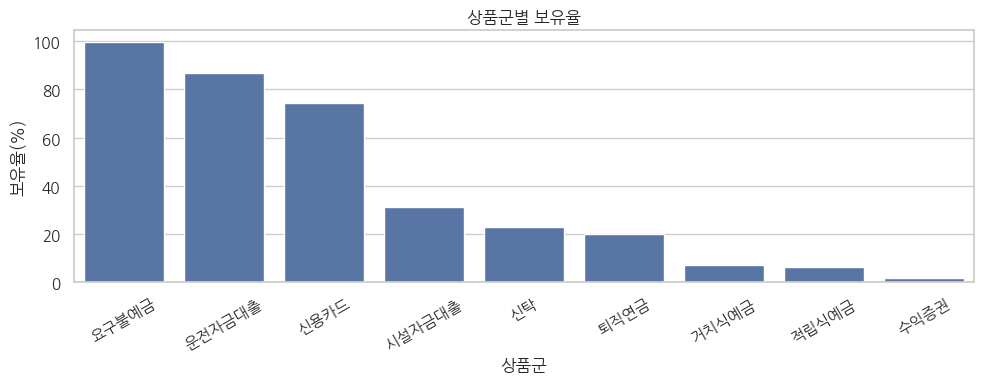

,보유상품수,고객수
0,0,2
1,1,125
2,2,2572
3,3,5071
4,4,1872
5,5,1336
6,6,1026
7,7,264
8,8,50
9,9,2


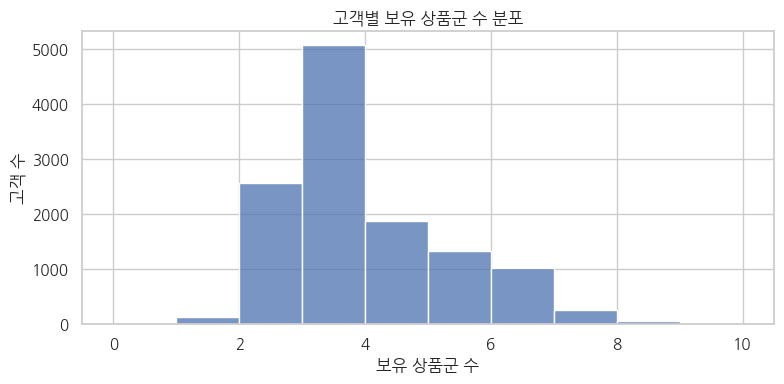

In [8]:
# ============================================================
# STEP 4. 고객-상품 보유 행렬 EDA
# - 상품별 보유 고객 수와 보유율 확인
# - 너무 보유율이 낮거나 높은 상품은 추천 품질에 영향을 줄 수 있음
# ============================================================

product_cols = list(product_col_map.keys())

product_summary = pd.DataFrame({
    "상품군": product_cols,
    "보유고객수": [holding_data[p].sum() for p in product_cols],
    "보유율(%)": [holding_data[p].mean() * 100 for p in product_cols]
})

product_summary["보유율(%)"] = product_summary["보유율(%)"].round(2)
product_summary = product_summary.sort_values("보유율(%)", ascending=False)

display(product_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=product_summary, x="상품군", y="보유율(%)")
plt.title("상품군별 보유율")
plt.xlabel("상품군")
plt.ylabel("보유율(%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 고객별 보유 상품 수
holding_data["보유상품수"] = holding_data[product_cols].sum(axis=1)

display(
    holding_data["보유상품수"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"보유상품수": "보유상품수", "count": "고객수"})
)

plt.figure(figsize=(8, 4))
sns.histplot(holding_data["보유상품수"], bins=range(0, len(product_cols) + 2))
plt.title("고객별 보유 상품군 수 분포")
plt.xlabel("보유 상품군 수")
plt.ylabel("고객 수")
plt.tight_layout()
plt.show()

,요구불예금,거치식예금,적립식예금,수익증권,신탁,퇴직연금,운전자금대출,시설자금대출,신용카드
요구불예금,1.000000,0.265468,0.248651,0.126117,0.477214,0.448307,0.932774,0.553909,0.864989
거치식예금,0.265468,1.000000,0.266600,0.085171,0.281379,0.255823,0.232575,0.163686,0.261489
적립식예금,0.248651,0.266600,1.000000,0.098840,0.230031,0.223725,0.235600,0.159160,0.260914
수익증권,0.126117,0.085171,0.098840,1.000000,0.169227,0.144148,0.123915,0.089987,0.136829
신탁,0.477214,0.281379,0.230031,0.169227,1.000000,0.939180,0.465837,0.368521,0.505313
퇴직연금,0.448307,0.255823,0.223725,0.144148,0.939180,1.000000,0.445217,0.351526,0.484653
운전자금대출,0.932774,0.232575,0.235600,0.123915,0.465837,0.445217,1.000000,0.387782,0.817959
시설자금대출,0.553909,0.163686,0.159160,0.089987,0.368521,0.351526,0.387782,1.000000,0.538095
신용카드,0.864989,0.261489,0.260914,0.136829,0.505313,0.484653,0.817959,0.538095,1.000000


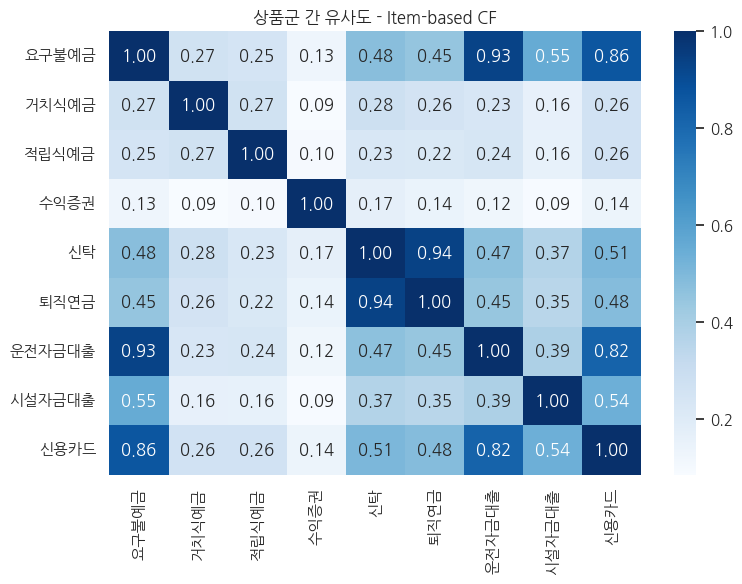

In [9]:
# ============================================================
# STEP 5. Item-based Collaborative Filtering
# - 상품 간 유사도를 계산
# - 함께 보유되는 경향이 높은 상품끼리 유사도가 높게 나옴
# - 고객이 이미 보유한 상품과 유사한 미보유 상품을 추천
# ============================================================

# 고객-상품 행렬
user_item = holding_data.set_index(id_col)[product_cols].astype(float)

# 상품 간 cosine similarity 계산
item_sim = cosine_similarity(user_item.T)

item_sim_df = pd.DataFrame(
    item_sim,
    index=product_cols,
    columns=product_cols
)

display(item_sim_df)

plt.figure(figsize=(8, 6))
sns.heatmap(item_sim_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("상품군 간 유사도 - Item-based CF")
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# CELL 12. 추천 성능 평가: Popularity / Item-CF / Random 비교
# - Train 기간의 상품 보유 패턴으로 추천
# - Test 기간에 새로 보유하게 된 상품을 맞혔는지 평가
# - 전체 고객 기준과 신규 보유 발생 고객 기준을 함께 확인
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. Train/Test 기간 설정
# - 마지막 12개월을 Test 기간으로 사용
# ------------------------------------------------------------

all_months = sorted(df_cf["기준년월_p"].unique())

test_months = all_months[-12:]
train_months = all_months[:-12]

print("Train 기간:", train_months[0], "~", train_months[-1])
print("Test 기간 :", test_months[0], "~", test_months[-1])

train_df = df_cf[df_cf["기준년월_p"].isin(train_months)].copy()
test_df = df_cf[df_cf["기준년월_p"].isin(test_months)].copy()

print("Train 법인 수:", train_df[id_col].nunique())
print("Test 법인 수 :", test_df[id_col].nunique())


# ------------------------------------------------------------
# 2. 고객-상품 보유 행렬 생성 함수
# - 보유 기준은 좌수/개수 > 0
# ------------------------------------------------------------

def make_holding_matrix(data, product_col_map, id_col="법인ID"):
    holding = pd.DataFrame({id_col: data[id_col].unique()})

    for product, col in product_col_map.items():
        num_col = product + "_좌수_num"

        if num_col not in data.columns:
            data[num_col] = product_count_to_num(data[col])

        temp = (
            data
            .groupby(id_col)[num_col]
            .max()
            .reset_index()
        )

        temp[product] = (temp[num_col] > 0).astype(int)

        holding = holding.merge(
            temp[[id_col, product]],
            on=id_col,
            how="left"
        )

    holding = holding.fillna(0)

    return holding.set_index(id_col)[list(product_col_map.keys())].astype(int)


train_matrix = make_holding_matrix(train_df, product_col_map, id_col=id_col)
test_matrix = make_holding_matrix(test_df, product_col_map, id_col=id_col)

# Train/Test 공통 고객만 평가
common_users = train_matrix.index.intersection(test_matrix.index)

train_matrix = train_matrix.loc[common_users]
test_matrix = test_matrix.loc[common_users]

print("평가 대상 공통 법인 수:", len(common_users))
print("상품군 수:", train_matrix.shape[1])


# ------------------------------------------------------------
# 3. 정답 생성
# - Train에는 없었고 Test에는 생긴 상품 = 신규 보유 상품
# ------------------------------------------------------------

new_item_matrix = ((train_matrix == 0) & (test_matrix == 1)).astype(int)

eval_users_positive = new_item_matrix[new_item_matrix.sum(axis=1) > 0].index

print("미래 신규 보유 상품이 있는 고객 수:", len(eval_users_positive))
print("전체 공통 고객 중 비율(%):", round(len(eval_users_positive) / len(common_users) * 100, 2))

display(
    new_item_matrix.sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "상품군", 0: "미래신규보유고객수"})
)


# ------------------------------------------------------------
# 4. Item-CF 학습
# ------------------------------------------------------------

item_sim = cosine_similarity(train_matrix.T)

item_sim_df_eval = pd.DataFrame(
    item_sim,
    index=train_matrix.columns,
    columns=train_matrix.columns
)


# ------------------------------------------------------------
# 5. 추천 함수 3종
# ------------------------------------------------------------

def recommend_item_cf(user_id, train_matrix, item_sim_df, top_k=3):
    user_vector = train_matrix.loc[user_id]

    owned_items = user_vector[user_vector > 0].index.tolist()
    candidate_items = user_vector[user_vector == 0].index.tolist()

    scores = {}

    for item in candidate_items:
        if len(owned_items) == 0:
            scores[item] = 0
        else:
            scores[item] = item_sim_df.loc[item, owned_items].mean()

    return (
        pd.Series(scores)
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )


def recommend_popularity(user_id, train_matrix, popularity_score, top_k=3):
    user_vector = train_matrix.loc[user_id]
    candidate_items = user_vector[user_vector == 0].index.tolist()

    return (
        popularity_score.loc[candidate_items]
        .sort_values(ascending=False)
        .head(top_k)
        .index
        .tolist()
    )


def recommend_random(user_id, train_matrix, top_k=3, seed=42):
    rng = np.random.default_rng(seed + abs(hash(user_id)) % 1000000)

    user_vector = train_matrix.loc[user_id]
    candidate_items = user_vector[user_vector == 0].index.tolist()

    if len(candidate_items) <= top_k:
        return candidate_items

    return rng.choice(candidate_items, size=top_k, replace=False).tolist()


# ------------------------------------------------------------
# 6. 평가지표 함수
# ------------------------------------------------------------

def apk(actual, predicted, k):
    predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1
            score += num_hits / (i + 1.0)

    if len(actual) == 0:
        return np.nan

    return score / min(len(actual), k)


def ndcg_at_k(actual, predicted, k):
    actual_set = set(actual)

    dcg = 0.0
    for i, p in enumerate(predicted[:k]):
        if p in actual_set:
            dcg += 1.0 / np.log2(i + 2)

    ideal_hits = min(len(actual), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

    if idcg == 0:
        return np.nan

    return dcg / idcg


def evaluate_model(model_name, recommend_func, users, k=3):
    rows = []

    for uid in users:
        actual_items = new_item_matrix.loc[uid]
        actual = actual_items[actual_items > 0].index.tolist()

        pred = recommend_func(uid, k)

        hit_cnt = len(set(actual) & set(pred))

        rows.append({
            id_col: uid,
            "actual_items": actual,
            "pred_items": pred,
            "hit": int(hit_cnt > 0),
            "precision": hit_cnt / k,
            "recall": hit_cnt / len(actual) if len(actual) > 0 else np.nan,
            "ap": apk(actual, pred, k),
            "ndcg": ndcg_at_k(actual, pred, k)
        })

    detail = pd.DataFrame(rows)

    metrics = {
        "모델": model_name,
        "K": k,
        "평가기준": "신규보유발생고객" if len(users) == len(eval_users_positive) else "전체공통고객",
        "HitRate@K": detail["hit"].mean(),
        "Precision@K": detail["precision"].mean(),
        "Recall@K": detail["recall"].mean(),
        "MAP@K": detail["ap"].mean(),
        "NDCG@K": detail["ndcg"].mean()
    }

    return metrics, detail


# ------------------------------------------------------------
# 7. 모델별 추천 함수 준비
# ------------------------------------------------------------

popularity_score = train_matrix.mean(axis=0)

def rec_item_cf(uid, k):
    return recommend_item_cf(uid, train_matrix, item_sim_df_eval, top_k=k)

def rec_popularity(uid, k):
    return recommend_popularity(uid, train_matrix, popularity_score, top_k=k)

def rec_random(uid, k):
    return recommend_random(uid, train_matrix, top_k=k, seed=42)


model_funcs = {
    "Popularity": rec_popularity,
    "Item-based CF": rec_item_cf,
    "Random": rec_random
}


# ------------------------------------------------------------
# 8. K별 평가 실행
# ------------------------------------------------------------

metrics_rows = []
eval_detail_dict = {}

for user_group_name, users in {
    "전체공통고객": common_users,
    "신규보유발생고객": eval_users_positive
}.items():

    for k in [1, 2, 3, 5]:
        for model_name, func in model_funcs.items():
            metrics, detail = evaluate_model(
                model_name=model_name,
                recommend_func=func,
                users=users,
                k=k
            )

            metrics["평가기준"] = user_group_name
            metrics_rows.append(metrics)
            eval_detail_dict[(user_group_name, model_name, k)] = detail

metrics_compare_df = pd.DataFrame(metrics_rows)

display(
    metrics_compare_df[
        [
            "평가기준",
            "모델",
            "K",
            "HitRate@K",
            "Precision@K",
            "Recall@K",
            "MAP@K",
            "NDCG@K"
        ]
    ].sort_values(["평가기준", "K", "모델"])
)


# ------------------------------------------------------------
# 9. 발표용 핵심 비교표
# - 추천 성능은 신규 보유 발생 고객 기준이 더 해석하기 좋음
# ------------------------------------------------------------

main_compare = metrics_compare_df[
    metrics_compare_df["평가기준"] == "신규보유발생고객"
].copy()

display(
    main_compare[
        [
            "모델",
            "K",
            "HitRate@K",
            "Precision@K",
            "Recall@K",
            "MAP@K",
            "NDCG@K"
        ]
    ].sort_values(["K", "NDCG@K"], ascending=[True, False])
)


# ------------------------------------------------------------
# 10. Top3 상세 결과 확인
# ------------------------------------------------------------

display(eval_detail_dict[("신규보유발생고객", "Item-based CF", 3)].head(20))

Train 기간: 2023-01 ~ 2024-12
Test 기간 : 2025-01 ~ 2025-12
Train 법인 수: 13971
Test 법인 수 : 12320
평가 대상 공통 법인 수: 10818
상품군 수: 9
미래 신규 보유 상품이 있는 고객 수: 649
전체 공통 고객 중 비율(%): 6.0


,상품군,미래신규보유고객수
0,신탁,165
1,신용카드,148
2,퇴직연금,138
3,적립식예금,127
4,거치식예금,108
5,운전자금대출,80
6,시설자금대출,73
7,수익증권,9
8,요구불예금,3


,평가기준,모델,K,HitRate@K,Precision@K,Recall@K,MAP@K,NDCG@K
13,신규보유발생고객,Item-based CF,1,0.556240,0.556240,0.470981,0.556240,0.556240
12,신규보유발생고객,Popularity,1,0.542373,0.542373,0.463277,0.542373,0.542373
14,신규보유발생고객,Random,1,0.249615,0.249615,0.195300,0.249615,0.249615
16,신규보유발생고객,Item-based CF,2,0.730354,0.432974,0.667309,0.612866,0.638569
15,신규보유발생고객,Popularity,2,0.728814,0.430663,0.665254,0.607088,0.633423
17,신규보유발생고객,Random,2,0.476117,0.251156,0.396893,0.303929,0.343032
19,신규보유발생고객,Item-based CF,3,0.816641,0.354391,0.795455,0.663071,0.701371
18,신규보유발생고객,Popularity,3,0.801233,0.347714,0.778249,0.651986,0.688772
20,신규보유발생고객,Random,3,0.676425,0.255778,0.595146,0.396935,0.462360
22,신규보유발생고객,Item-based CF,5,0.983051,0.257319,0.980611,0.713236,0.781922


,모델,K,HitRate@K,Precision@K,Recall@K,MAP@K,NDCG@K
13,Item-based CF,1,0.556240,0.556240,0.470981,0.556240,0.556240
12,Popularity,1,0.542373,0.542373,0.463277,0.542373,0.542373
14,Random,1,0.249615,0.249615,0.195300,0.249615,0.249615
16,Item-based CF,2,0.730354,0.432974,0.667309,0.612866,0.638569
15,Popularity,2,0.728814,0.430663,0.665254,0.607088,0.633423
17,Random,2,0.476117,0.251156,0.396893,0.303929,0.343032
19,Item-based CF,3,0.816641,0.354391,0.795455,0.663071,0.701371
18,Popularity,3,0.801233,0.347714,0.778249,0.651986,0.688772
20,Random,3,0.676425,0.255778,0.595146,0.396935,0.462360
22,Item-based CF,5,0.983051,0.257319,0.980611,0.713236,0.781922


,법인ID,actual_items,pred_items,hit,precision,recall,ap,ndcg
0,00a0049e060729db59e6f8e15bbc7e0f31b921e34f16299c90e83272dc06a34b,"[시설자금대출, 신용카드]","[신용카드, 시설자금대출, 신탁]",1,0.666667,1.000000,1.000000,1.000000
1,017f886c21c6d165148a88428f7d6124e226c188f2bb10db58e1c865cfe6c68f,[거치식예금],"[시설자금대출, 거치식예금, 적립식예금]",1,0.333333,1.000000,0.500000,0.630930
2,025b3448c92efc8caa594f460e7d9567e0f84e599ddb37fd93d5105fc0d3a885,[적립식예금],"[시설자금대출, 신탁, 퇴직연금]",0,0.000000,0.000000,0.000000,0.000000
3,02630ff1a359d4b5fc1997188cac7da64b79dbe0d112d0864ae7ea0ae4ddbee6,[신용카드],"[신용카드, 거치식예금, 적립식예금]",1,0.333333,1.000000,1.000000,1.000000
4,02ab3602a4e6d52462a9e636e91b771afe941d188ec8f346a00fc047e9c21164,[거치식예금],"[운전자금대출, 신탁, 퇴직연금]",0,0.000000,0.000000,0.000000,0.000000
5,030ef11c7c8cf226593c8af27678b37a1cc81a384c5c002f1605aaf12aa88c40,"[신탁, 퇴직연금]","[시설자금대출, 신탁, 퇴직연금]",1,0.666667,1.000000,0.583333,0.693426
6,032d6bd8bcea12a01818726e09542b211d187c96fbbe1bfbecf238d861d44fd2,[거치식예금],"[거치식예금, 수익증권]",1,0.333333,1.000000,1.000000,1.000000
7,03b35498d0a85b0707cc223a8524949c6aa14f488f4ed306479cf44d57ea95a4,[거치식예금],"[시설자금대출, 거치식예금, 적립식예금]",1,0.333333,1.000000,0.500000,0.630930
8,04caeb054304ece3bdf3c1e17939c9441c5165a20535a08ac32599292efeafc5,[시설자금대출],"[시설자금대출, 신탁, 퇴직연금]",1,0.333333,1.000000,1.000000,1.000000
9,051479ed103c854c3d3a3fa329ba0a9a9db6355ed47bd359aca1dbfb1f44d563,[적립식예금],"[신탁, 시설자금대출, 퇴직연금]",0,0.000000,0.000000,0.000000,0.000000


In [21]:
# ============================================================
# [재설계 0] 공통 준비 — df_cf / product_col_map / period 재사용
# ============================================================
import numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
try:
    from lightgbm import LGBMClassifier; HAS_LGBM=True
except Exception:
    HAS_LGBM=False
from sklearn.ensemble import HistGradientBoostingClassifier

PRODUCTS=list(product_col_map.keys())
NUMCOL={p:p+'_좌수_num' for p in PRODUCTS}  # 이미 생성된 좌수 숫자 컬럼

def _count_to_num(s):
    if pd.api.types.is_numeric_dtype(s): return pd.to_numeric(s,errors='coerce').fillna(0)
    mp={'0개':0,'1개':1,'2개':2,'2개초과5개이하':3,'5개초과10개이하':6,'10개초과20개이하':11,
        '20개초과30개이하':21,'30개초과40개이하':31,'40개초과50개이하':41,'50개초과':51,
        '0건':0,'1건':1,'2건':2,'2건초과5건이하':3,'5건초과10건이하':6,'10건초과20건이하':11,
        '20건초과30건이하':21,'30건초과40건이하':31,'40건초과50건이하':41,'50건초과':51}
    return s.astype(str).str.replace(' ','',regex=False).map(mp).fillna(0)
def _amt_to_num(s):
    if pd.api.types.is_numeric_dtype(s): return pd.to_numeric(s,errors='coerce').fillna(0)
    return pd.to_numeric(s.astype(str).str.replace(',','',regex=False).str.extract(r'(-?\d+\.?\d*)')[0],errors='coerce').fillna(0)

df_cf['_year']=df_cf['기준년월_p'].dt.year
def period_df(year): return df_cf[df_cf['_year']==year]
print('연도별 행수:', df_cf['_year'].value_counts().sort_index().to_dict())

연도별 행수: {2023: 121074, 2024: 122146, 2025: 122768}


In [40]:
# ============================================================
# [재설계 1] 기간별 보유행렬 / 신규보유행렬 / 고객피처 함수
# - 원본 컬럼 기준 피처 생성
# - 수치형 피처는 mean / max만 사용
# - 전담고객여부는 원핫인코딩하지 않고 Y=1, 그 외=0 단일 피처로 처리
# ============================================================

# 원본 데이터 컬럼 기준 저장
# 데이터 로드 셀에서 이미 만들었다면 그대로 사용됨
if "original_columns" not in globals():
    original_columns = df.columns.tolist()


def make_holding_matrix_by_period(df_period):
    # 해당 기간 중 한 번이라도 좌수 > 0이면 보유(1)
    out = pd.DataFrame(index=sorted(df_period[id_col].unique()))

    for p in PRODUCTS:
        m = df_period.groupby(id_col)[NUMCOL[p]].max()
        out[p] = (m.reindex(out.index).fillna(0) > 0).astype(int)

    return out


def make_new_item_matrix(base_matrix, future_matrix):
    # base=0 & future=1 -> 신규보유(1)
    # 단, 두 기간 모두 관측된 고객만 사용
    # 과거 기간에 관측되지 않은 고객은 '미보유'가 아니라 '정보 없음'이므로 제외

    idx = base_matrix.index.intersection(future_matrix.index)

    b = base_matrix.loc[idx]
    f = future_matrix.loc[idx]

    return ((b == 0) & (f == 1)).astype(int)


def make_customer_features_by_period(df_period, hold_matrix):
    ids = sorted(df_period[id_col].unique())
    base = pd.DataFrame(index=ids)

    # ------------------------------------------------------------
    # 1. 수치형 원천 컬럼 선정
    # - 원본 데이터에 실제로 있던 컬럼만 사용
    # - 중간에 만든 *_num, _year 같은 파생 컬럼이 다시 들어가는 것 방지
    # ------------------------------------------------------------

    num_src = [
        c for c in original_columns
        if c in df_period.columns
        and any(k in c for k in ["잔액", "금액", "한도", "거래건수", "개수", "좌수"])
        and c not in [id_col, date_col]
    ]

    frames = []

    df_work = df_period.copy()
    df_work = df_work.sort_values([id_col, "기준년월_p"])

    # ------------------------------------------------------------
    # 2. 수치형 피처 생성
    # - 연도 평균(mean)
    # - 연도 최대값(max)
    # ------------------------------------------------------------

    for c in num_src:
        if ("좌수" in c) or ("개수" in c) or ("거래건수" in c):
            v = _count_to_num(df_work[c])
        else:
            v = _amt_to_num(df_work[c])

        tmp = pd.DataFrame({
            id_col: df_work[id_col].values,
            c: v.values
        })

        agg = tmp.groupby(id_col)[c].agg(
            mean="mean",
            max="max"
        )

        agg = agg.rename(columns={
            "mean": f"{c}_mean",
            "max": f"{c}_max"
        })

        frames.append(agg)

    if len(frames) > 0:
        X_num = pd.concat(frames, axis=1)
        X_num = X_num.loc[:, ~X_num.columns.duplicated(keep="first")]
    else:
        X_num = pd.DataFrame(index=ids)

    # ------------------------------------------------------------
    # 3. 상품 보유 플래그 + 보유상품수
    # ------------------------------------------------------------

    hold_aligned = hold_matrix.reindex(ids).fillna(0)

    X_hold = hold_aligned.add_prefix("보유_")
    X_hold["보유상품수"] = hold_aligned.sum(axis=1)

    # ------------------------------------------------------------
    # 4. 일반 범주형 피처
    # - 전담고객여부는 여기서 제외
    # ------------------------------------------------------------

    cat = [
        c for c in [
            "업종_대분류",
            "업종_중분류",
            "사업장_시도",
            "사업장_시군구",
            "법인_고객등급"
        ]
        if c in df_period.columns
    ]

    if cat:
        raw = df_period.groupby(id_col)[cat].agg(
            lambda s: s.dropna().mode().iloc[0]
            if len(s.dropna().mode()) > 0
            else "미상"
        )

        raw = raw.fillna("미상").astype(str)

        X_cat = pd.get_dummies(
            raw,
            dummy_na=False
        ).astype(int)

        X_cat = X_cat.loc[:, ~X_cat.columns.duplicated(keep="first")]
    else:
        X_cat = pd.DataFrame(index=ids)

    # ------------------------------------------------------------
    # 5. 전담고객여부 단일 피처 생성
    # - Y면 1
    # - N 또는 결측이면 0
    # ------------------------------------------------------------

    if "전담고객여부" in df_period.columns:
        yn_raw = df_period.groupby(id_col)["전담고객여부"].agg(
            lambda s: s.dropna().mode().iloc[0]
            if len(s.dropna().mode()) > 0
            else "N"
        )

        X_yn = (
            yn_raw.astype(str)
            .str.strip()
            .str.upper()
            .eq("Y")
            .astype(int)
            .to_frame("전담고객여부")
        )

        X_cat = pd.concat([X_cat, X_yn], axis=1)

    # ------------------------------------------------------------
    # 6. 최종 피처 결합
    # ------------------------------------------------------------

    X = pd.concat([base, X_num, X_hold, X_cat], axis=1)

    # 중복 컬럼 방지
    X = X.loc[:, ~X.columns.duplicated(keep="first")]

    # 혹시 이전 원핫 전담여부 컬럼이 남아 있으면 제거
    drop_cols = ["전담고객여부_N", "전담고객여부_Y", "전담고객여부_미상"]
    X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

    return X.fillna(0)


print("재설계 1 함수 정의 완료")

재설계 1 함수 정의 완료


In [41]:
# ============================================================
# [재설계 2] 연도별 행렬/신규보유/피처 생성
# ============================================================
df23, df24, df25 = period_df(2023), period_df(2024), period_df(2025)

matrix_2023 = make_holding_matrix_by_period(df23)
matrix_2024 = make_holding_matrix_by_period(df24)
matrix_2025 = make_holding_matrix_by_period(df25)

new_item_train = make_new_item_matrix(matrix_2023, matrix_2024)   # 2023미보유→2024보유
new_item_test  = make_new_item_matrix(matrix_2024, matrix_2025)   # 2024미보유→2025보유

feat_2023 = make_customer_features_by_period(df23, matrix_2023)   # ML 학습 입력
feat_2024 = make_customer_features_by_period(df24, matrix_2024)   # ML 예측/평가 입력

# 피처 컬럼 정렬(학습=2023 기준) → 2024를 동일 컬럼으로 reindex (누수/불일치 방지)
feat_cols = feat_2023.columns
feat_2024 = feat_2024.reindex(columns=feat_cols, fill_value=0)

# 공통 고객
common_23_24 = matrix_2023.index.intersection(matrix_2024.index)
common_24_25 = matrix_2024.index.intersection(matrix_2025.index)

# 최종 평가 대상: 2024와 2025에 모두 존재하면서 2025 신규보유가 발생한 고객
final_eval_users = new_item_test.index[new_item_test.sum(axis=1) > 0]

# 평가/추천은 2024에 존재하고 2024 피처가 있는 고객만 가능
final_eval_users = final_eval_users.intersection(matrix_2024.index).intersection(feat_2024.index)

print("[기간별 고객 수]")
print(" 2023:", matrix_2023.shape[0])
print(" 2024:", matrix_2024.shape[0])
print(" 2025:", matrix_2025.shape[0])
print(" 2023∩2024 공통:", len(common_23_24))
print(" 2024∩2025 공통:", len(common_24_25))
print(" 2025 신규보유 발생 평가 고객(final_eval_users):", len(final_eval_users))

[기간별 고객 수]
 2023: 12174
 2024: 12364
 2025: 12320
 2023∩2024 공통: 10567
 2024∩2025 공통: 10762
 2025 신규보유 발생 평가 고객(final_eval_users): 653


In [25]:
# ============================================================
# [재설계 3] 평가지표 + 점수행렬 추천/평가 함수 (동일 기준)
# ============================================================
def _apk(actual,pred,k):
    if len(actual)==0: return np.nan
    pred=pred[:k]; s=0.0; h=0.0
    for i,p in enumerate(pred):
        if p in actual and p not in pred[:i]: h+=1; s+=h/(i+1)
    return s/min(len(actual),k)
def _ndcg(actual,pred,k):
    if len(actual)==0: return np.nan
    pred=pred[:k]; dcg=sum(1/np.log2(i+2) for i,p in enumerate(pred) if p in actual)
    idcg=sum(1/np.log2(i+2) for i in range(min(len(actual),k)))
    return dcg/idcg if idcg>0 else np.nan
def _minmax_row(df):
    a=df.values.astype(float); mn=np.nanmin(a,axis=1,keepdims=True); mx=np.nanmax(a,axis=1,keepdims=True)
    d=mx-mn; return pd.DataFrame(np.where(d==0,0,(a-mn)/d),index=df.index,columns=df.columns)
def _recommend(score_df, base_matrix, users, k):
    out={}
    for u in users:
        s=score_df.loc[u].copy(); owned=base_matrix.loc[u]
        s[owned==1]=-np.inf
        out[u]=s.sort_values(ascending=False).head(k).index.tolist()
    return out
def evaluate_score_matrix(score_df, base_matrix, new_item, users, k):
    pred=_recommend(score_df, base_matrix, users, k); rows=[]
    for u,pr in pred.items():
        act=new_item.loc[u]; act=act[act==1].index.tolist()
        inter=len(set(act)&set(pr))
        rows.append((int(inter>0), inter/k, inter/len(act) if act else np.nan, _apk(act,pr,k), _ndcg(act,pr,k)))
    d=pd.DataFrame(rows,columns=['hit','prec','rec','ap','ndcg'])
    return {'HitRate':d['hit'].mean(),'Precision':d['prec'].mean(),'Recall':d['rec'].mean(),
            'MAP':d['ap'].mean(),'NDCG':d['ndcg'].mean()}
print('평가 함수 정의 완료')

평가 함수 정의 완료


In [26]:
# ============================================================
# [재설계 4] 점수행렬 5종 생성 (Random / Popularity / CF / ML / Hybrid)
#  - 모두 users = matrix_2024.index 기준으로 만들고, 평가만 final_eval_users로
# ============================================================
USERS=matrix_2024.index
PCOLS=PRODUCTS

# (A) Random
rng=np.random.default_rng(42)
score_random=pd.DataFrame(rng.random((len(USERS),len(PCOLS))),index=USERS,columns=PCOLS)

# (B) Popularity (2024 보유빈도)
pop=matrix_2024.mean(axis=0)
score_pop=pd.DataFrame(np.tile(pop.values,(len(USERS),1)),index=USERS,columns=PCOLS)

# (C) Item-based CF (2024 보유행렬 기반)
item_sim=cosine_similarity(matrix_2024[PCOLS].T.values); np.fill_diagonal(item_sim,0)
denom=np.abs(item_sim).sum(axis=1)+1e-9
cf_raw=matrix_2024[PCOLS].values.dot(item_sim)/denom
score_cf=pd.DataFrame(cf_raw,index=matrix_2024.index,columns=PCOLS).reindex(USERS)

# (D) ML: 상품별 2023피처→2024신규보유 학습, 2024피처→2025확률 예측
def make_ml():
    if HAS_LGBM: return LGBMClassifier(n_estimators=300,learning_rate=0.05,num_leaves=31,random_state=42,n_jobs=-1)
    return HistGradientBoostingClassifier(max_iter=300,learning_rate=0.05,random_state=42)
# 학습 고객: 2023 피처 ∩ 2024 신규보유라벨 존재
tr_users=feat_2023.index.intersection(new_item_train.index)
Xtr=feat_2023.loc[tr_users]
score_ml=pd.DataFrame(index=USERS,columns=PCOLS,dtype=float)
ml_auc={}
from sklearn.metrics import roc_auc_score
for p in PCOLS:
    y=new_item_train[p].reindex(tr_users).fillna(0).astype(int)
    if y.sum()<10 or y.nunique()<2:
        score_ml[p]=pop[p]  # fallback: popularity
        continue
    m=make_ml(); m.fit(Xtr.values,y.values)
    proba=m.predict_proba(feat_2024.reindex(USERS).fillna(0).values)[:,1]
    score_ml[p]=proba
    try: ml_auc[p]=roc_auc_score(y.values,m.predict_proba(Xtr.values)[:,1])
    except Exception: pass
score_ml=score_ml.astype(float)
print('ML 학습 완료 | 상품별 train-AUC(참고):')
print(pd.Series(ml_auc).round(3).to_string() if ml_auc else '(fallback 위주)')

# 정규화 (Hybrid 합산용)
cf_n=_minmax_row(score_cf.fillna(0)); ml_n=_minmax_row(score_ml.fillna(0))
print('\n점수행렬 5종 생성 완료')

[LightGBM] [Info] Number of positive: 127, number of negative: 10440
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14769
[LightGBM] [Info] Number of data points in the train set: 10567, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.012019 -> initscore=-4.409213
[LightGBM] [Info] Start training from score -4.409213


/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 104, number of negative: 10463
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004801 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14769
[LightGBM] [Info] Number of data points in the train set: 10567, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.009842 -> initscore=-4.611210
[LightGBM] [Info] Start training from score -4.611210


/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 15, number of negative: 10552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14769
[LightGBM] [Info] Number of data points in the train set: 10567, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001420 -> initscore=-6.556020
[LightGBM] [Info] Start training from score -6.556020
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

...

/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 91, number of negative: 10476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14769
[LightGBM] [Info] Number of data points in the train set: 10567, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.008612 -> initscore=-4.745983
[LightGBM] [Info] Start training from score -4.745983


/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 116, number of negative: 10451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14769
[LightGBM] [Info] Number of data points in the train set: 10567, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010978 -> initscore=-4.500863
[LightGBM] [Info] Start training from score -4.500863
ML 학습 완료 | 상품별 train-AUC(참고):
거치식예금     1.0
적립식예금     1.0
수익증권      1.0
신탁        1.0
퇴직연금      1.0
운전자금대출    1.0
시설자금대출    1.0
신용카드      1.0

점수행렬 5종 생성 완료


/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_371599/2591508977.py:17: RuntimeWarning: invalid value encountered in divide
  d=mx-mn; return pd.DataFrame(np.where(d==0,0,(a-mn)/d),index=df.index,columns=df.columns)


In [27]:
# ============================================================
# [재설계 5] 모델별 성능 비교표 (동일 final_eval_users / K=1,2,3,5)
# ============================================================
Ks=[1,2,3,5]
models={'Random':score_random,'Popularity':score_pop,'Item-CF':score_cf,
        'ML단독':score_ml,'Hybrid(α=0.5)':_minmax_row(score_cf.fillna(0))*0.5+_minmax_row(score_ml.fillna(0))*0.5}
rows=[]
for name,sdf in models.items():
    for k in Ks:
        r=evaluate_score_matrix(sdf, matrix_2024, new_item_test, final_eval_users, k)
        rows.append({'모델':name,'K':k,**{m:round(r[m],4) for m in ['HitRate','Precision','Recall','MAP','NDCG']}})
perf=pd.DataFrame(rows)
print('평가 고객 수(공통):', len(final_eval_users))
for k in Ks:
    print(f'\n=== K={k} ===')
    print(perf[perf['K']==k].drop(columns='K').to_string(index=False))

/tmp/ipykernel_371599/2591508977.py:17: RuntimeWarning: invalid value encountered in divide
  d=mx-mn; return pd.DataFrame(np.where(d==0,0,(a-mn)/d),index=df.index,columns=df.columns)


평가 고객 수(공통): 653

=== K=1 ===
           모델  HitRate  Precision  Recall    MAP   NDCG
       Random   0.2588     0.2588  0.1983 0.2588 0.2588
   Popularity   0.5283     0.5283  0.4530 0.5283 0.5283
      Item-CF   0.5191     0.5191  0.4507 0.5191 0.5191
         ML단독   0.4640     0.4640  0.3888 0.4640 0.4640
Hybrid(α=0.5)   0.5191     0.5191  0.4507 0.5191 0.5191

=== K=2 ===
           모델  HitRate  Precision  Recall    MAP   NDCG
       Random   0.4686     0.2534  0.3932 0.3116 0.3478
   Popularity   0.7198     0.4227  0.6553 0.5949 0.6219
      Item-CF   0.7090     0.4020  0.6683 0.5915 0.6198
         ML단독   0.6998     0.3798  0.6115 0.5214 0.5621
Hybrid(α=0.5)   0.7090     0.4012  0.6668 0.5904 0.6189

=== K=3 ===
           모델  HitRate  Precision  Recall    MAP   NDCG
       Random   0.6616     0.2506  0.5873 0.3777 0.4449
   Popularity   0.7979     0.3451  0.7755 0.6431 0.6813
      Item-CF   0.8116     0.3170  0.7811 0.6278 0.6728
         ML단독   0.8392     0.3313  0.7782 0.5849

In [50]:
# ============================================================
# [추가 실험] ML 모델별 성능 비교 + CF/ML 5:5 Hybrid
# - CatBoost 제외 버전
# - 가중치 탐색 제거
# - 모든 모델은 Hybrid = 0.5 * CF + 0.5 * ML 방식으로 고정
# - ML 단독 결과는 출력하지 않음
# - Baseline(Random / Popularity / Item-CF)과 Hybrid만 비교
# - 2023 피처 -> 2024 신규보유 학습
# - 2024 피처 -> 2025 신규보유 확률 예측
# ============================================================

import numpy as np
import pandas as pd
import copy

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print("LightGBM 사용 불가:", e)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("XGBoost 사용 불가:", e)


# ------------------------------------------------------------
# 0. row-wise min-max 정규화 함수
# - CF 점수와 ML 점수의 스케일을 맞추기 위해 고객 단위 정규화
# ------------------------------------------------------------

def _minmax_row_safe(df):
    a = df.values.astype(float)

    mn = np.nanmin(a, axis=1, keepdims=True)
    mx = np.nanmax(a, axis=1, keepdims=True)
    d = mx - mn

    out = np.zeros_like(a, dtype=float)
    np.divide(a - mn, d, out=out, where=(d != 0))

    return pd.DataFrame(out, index=df.index, columns=df.columns)


# ------------------------------------------------------------
# 1. 모델 후보 정의
# ------------------------------------------------------------

def get_model_candidates():
    models = {}

    models["LogisticRegression"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        ))
    ])

    models["RandomForest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            class_weight="balanced_subsample",
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ))
    ])

    models["ExtraTrees"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=441,
            max_depth=27,
            min_samples_leaf=21,
            min_samples_split=23,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    models["HistGradientBoosting"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ])

    if HAS_LGBM:
        models["LightGBM"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                verbose=-1
            ))
        ])

    if HAS_XGB:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=5,
                min_child_weight=5,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ])

    return models


model_candidates = get_model_candidates()

print("사용 가능 모델:")
print(list(model_candidates.keys()))


# ------------------------------------------------------------
# 2. 상품별 ML 예측 점수 생성 함수
# ------------------------------------------------------------

def make_ml_score_by_model(model_name, base_model, min_positive=10):
    """
    상품별로 신규보유 예측 모델을 학습하고,
    2024 고객 피처 기준으로 2025 신규보유 확률을 예측한다.
    """

    USERS = matrix_2024.index
    PCOLS = matrix_2024.columns.tolist()

    # 학습 고객: 2023 피처와 2024 신규보유 라벨이 모두 있는 고객
    train_users = feat_2023.index.intersection(new_item_train.index)
    X_train_all = feat_2023.loc[train_users].copy()

    # 예측 고객: 2024 피처가 있고, 2024 보유행렬에 존재하는 고객
    X_test_all = feat_2024.reindex(USERS).fillna(0).copy()

    score_ml = pd.DataFrame(
        0.0,
        index=USERS,
        columns=PCOLS
    )

    model_info = []

    for item in PCOLS:
        # 해당 상품을 2023년에 미보유했던 고객만 학습 대상으로 사용
        at_risk_matrix = matrix_2023.reindex(train_users).fillna(0)
        at_risk_users = at_risk_matrix.index[at_risk_matrix[item] == 0]

        X_item = X_train_all.loc[at_risk_users]
        y_item = new_item_train.loc[at_risk_users, item].fillna(0).astype(int)

        pos = int(y_item.sum())
        neg = int((y_item == 0).sum())

        # 양성 샘플이 너무 적으면 평균 발생률로 fallback
        if y_item.nunique() < 2 or pos < min_positive:
            fallback_prob = y_item.mean() if len(y_item) > 0 else 0
            score_ml[item] = fallback_prob

            model_info.append({
                "모델": model_name,
                "상품군": item,
                "학습방식": "fallback_mean",
                "학습고객수": len(y_item),
                "양성수": pos,
                "음성수": neg
            })
            continue

        model = copy.deepcopy(base_model)

        try:
            model.fit(X_item, y_item)
            pred_prob = model.predict_proba(X_test_all)[:, 1]
        except Exception as e:
            print(f"[{model_name}] {item} 학습 실패 -> fallback 사용:", e)
            pred_prob = np.repeat(y_item.mean(), len(X_test_all))

        score_ml[item] = pred_prob

        model_info.append({
            "모델": model_name,
            "상품군": item,
            "학습방식": "model",
            "학습고객수": len(y_item),
            "양성수": pos,
            "음성수": neg
        })

    return score_ml.astype(float), pd.DataFrame(model_info)


# ------------------------------------------------------------
# 3. Baseline 성능 기록
# ------------------------------------------------------------

k_list = [1, 2, 3, 5]

result_rows = []
model_info_list = []
score_dict = {}

# CF 점수 정규화
cf_n = _minmax_row_safe(score_cf.fillna(0))

baseline_scores = {
    "Random": score_random,
    "Popularity": score_pop,
    "Item-CF": score_cf
}

for base_name, base_score in baseline_scores.items():
    for k in k_list:
        r = evaluate_score_matrix(
            score_df=base_score,
            base_matrix=matrix_2024,
            new_item=new_item_test,
            users=final_eval_users,
            k=k
        )

        result_rows.append({
            "모델구분": "Baseline",
            "모델": base_name,
            "결합방식": "-",
            "K": k,
            **r
        })


# ------------------------------------------------------------
# 4. 모델별 Hybrid 5:5 평가
# - ML 단독 결과는 만들지 않음
# ------------------------------------------------------------

for model_name, model_obj in model_candidates.items():
    print(f"\n===== {model_name} 학습 및 Hybrid 평가 중 =====")

    score_ml_model, info_df = make_ml_score_by_model(
        model_name=model_name,
        base_model=model_obj,
        min_positive=10
    )

    model_info_list.append(info_df)
    score_dict[model_name] = score_ml_model

    # ML 점수 정규화
    ml_n = _minmax_row_safe(score_ml_model.fillna(0))

    # Hybrid 5:5
    hybrid_55_score = 0.5 * cf_n + 0.5 * ml_n

    for k in k_list:
        r = evaluate_score_matrix(
            score_df=hybrid_55_score,
            base_matrix=matrix_2024,
            new_item=new_item_test,
            users=final_eval_users,
            k=k
        )

        result_rows.append({
            "모델구분": "Hybrid",
            "모델": model_name,
            "결합방식": "CF 50% + ML 50%",
            "K": k,
            **r
        })


model_compare_result = pd.DataFrame(result_rows)
model_info_result = pd.concat(model_info_list, ignore_index=True) if model_info_list else pd.DataFrame()


# ------------------------------------------------------------
# 5. K=3 기준 최종 비교
# ------------------------------------------------------------

result_k3 = (
    model_compare_result[model_compare_result["K"] == 3]
    .sort_values(["NDCG", "MAP", "HitRate", "Precision"], ascending=False)
    .reset_index(drop=True)
)

display(result_k3)

best_row = result_k3.iloc[0]

print("\n[최종 후보 조합 - K=3 기준]")
print("모델구분:", best_row["모델구분"])
print("모델:", best_row["모델"])
print("결합방식:", best_row["결합방식"])
print("평가 고객 수:", len(final_eval_users))
print("NDCG@3:", round(best_row["NDCG"], 4))
print("MAP@3:", round(best_row["MAP"], 4))
print("HitRate@3:", round(best_row["HitRate"], 4))
print("Precision@3:", round(best_row["Precision"], 4))
print("Recall@3:", round(best_row["Recall"], 4))


# ------------------------------------------------------------
# 6. 모델별 최고 성능 요약
# ------------------------------------------------------------

best_by_model = (
    model_compare_result[model_compare_result["K"] == 3]
    .sort_values(["NDCG", "MAP", "HitRate"], ascending=False)
    .groupby(["모델구분", "모델"], as_index=False)
    .head(1)
    .sort_values(["NDCG", "MAP", "HitRate"], ascending=False)
    .reset_index(drop=True)
)

display(best_by_model)


# ------------------------------------------------------------
# 7. 상품별 학습 양성 수 확인
# ------------------------------------------------------------

display(
    model_info_result
    .sort_values(["모델", "양성수"])
    .reset_index(drop=True)
)

print("\n생성 변수:")
print("- model_compare_result")
print("- model_info_result")
print("- score_dict")

사용 가능 모델:
['LogisticRegression', 'RandomForest', 'ExtraTrees', 'HistGradientBoosting', 'LightGBM', 'XGBoost']



===== LogisticRegression 학습 및 Hybrid 평가 중 =====

===== RandomForest 학습 및 Hybrid 평가 중 =====

===== ExtraTrees 학습 및 Hybrid 평가 중 =====

===== HistGradientBoosting 학습 및 Hybrid 평가 중 =====

===== LightGBM 학습 및 Hybrid 평가 중 =====


/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/campus4d006/anaconda3/envs/chatbot/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X d


===== XGBoost 학습 및 Hybrid 평가 중 =====


,모델구분,모델,결합방식,K,HitRate,Precision,Recall,MAP,NDCG
0,Hybrid,ExtraTrees,CF 50% + ML 50%,3,0.886677,0.356815,0.847626,0.657053,0.712897
1,Hybrid,RandomForest,CF 50% + ML 50%,3,0.888208,0.352221,0.838948,0.654586,0.710827
2,Hybrid,XGBoost,CF 50% + ML 50%,3,0.857580,0.335886,0.808321,0.637315,0.690172
3,Hybrid,LogisticRegression,CF 50% + ML 50%,3,0.866769,0.334865,0.812532,0.627574,0.684919
4,Baseline,Popularity,-,3,0.797856,0.345074,0.775523,0.643058,0.681282
5,Hybrid,LightGBM,CF 50% + ML 50%,3,0.842266,0.325676,0.796197,0.618640,0.673018
6,Baseline,Item-CF,-,3,0.811639,0.316998,0.781138,0.627786,0.672763
7,Hybrid,HistGradientBoosting,CF 50% + ML 50%,3,0.820827,0.319040,0.783435,0.621661,0.670234
8,Baseline,Random,-,3,0.661562,0.250638,0.587289,0.377744,0.444915



[최종 후보 조합 - K=3 기준]
모델구분: Hybrid
모델: ExtraTrees
결합방식: CF 50% + ML 50%
평가 고객 수: 653
NDCG@3: 0.7129
MAP@3: 0.6571
HitRate@3: 0.8867
Precision@3: 0.3568
Recall@3: 0.8476


,모델구분,모델,결합방식,K,HitRate,Precision,Recall,MAP,NDCG
0,Hybrid,ExtraTrees,CF 50% + ML 50%,3,0.886677,0.356815,0.847626,0.657053,0.712897
1,Hybrid,RandomForest,CF 50% + ML 50%,3,0.888208,0.352221,0.838948,0.654586,0.710827
2,Hybrid,XGBoost,CF 50% + ML 50%,3,0.857580,0.335886,0.808321,0.637315,0.690172
3,Hybrid,LogisticRegression,CF 50% + ML 50%,3,0.866769,0.334865,0.812532,0.627574,0.684919
4,Baseline,Popularity,-,3,0.797856,0.345074,0.775523,0.643058,0.681282
5,Hybrid,LightGBM,CF 50% + ML 50%,3,0.842266,0.325676,0.796197,0.618640,0.673018
6,Baseline,Item-CF,-,3,0.811639,0.316998,0.781138,0.627786,0.672763
7,Hybrid,HistGradientBoosting,CF 50% + ML 50%,3,0.820827,0.319040,0.783435,0.621661,0.670234
8,Baseline,Random,-,3,0.661562,0.250638,0.587289,0.377744,0.444915


,모델,상품군,학습방식,학습고객수,양성수,음성수
0,ExtraTrees,요구불예금,fallback_mean,65,3,62
1,ExtraTrees,수익증권,model,10337,15,10322
2,ExtraTrees,시설자금대출,model,7087,91,6996
3,ExtraTrees,운전자금대출,model,1382,93,1289
4,ExtraTrees,적립식예금,model,9823,104,9719
5,ExtraTrees,퇴직연금,model,8330,110,8220
6,ExtraTrees,신용카드,model,2280,116,2164
7,ExtraTrees,거치식예금,model,9767,127,9640
8,ExtraTrees,신탁,model,8055,139,7916
9,HistGradientBoosting,요구불예금,fallback_mean,65,3,62



생성 변수:
- model_compare_result
- model_info_result
- score_dict


In [51]:
# ------------------------------------------------------------
# K=3 기준 Hybrid 모델만 비교
# - Baseline(Random / Popularity / Item-CF)은 출력에서 제외
# - 목적: Hybrid 방식에서 어떤 ML 모델을 결합했을 때 가장 좋은지 비교
# ------------------------------------------------------------

result_k3 = (
    model_compare_result[
        (model_compare_result["K"] == 3) &
        (model_compare_result["모델구분"] == "Hybrid")
    ]
    .sort_values(["NDCG", "MAP", "HitRate", "Precision"], ascending=False)
    .reset_index(drop=True)
)

display(
    result_k3
    .style
    .format({
        "HitRate": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "MAP": "{:.6f}",
        "NDCG": "{:.6f}"
    })
    .highlight_max(
        subset=["NDCG", "MAP", "HitRate", "Precision"],
        color="#fff59d"
    )
)

best_row = result_k3.iloc[0]

print("\n[Hybrid 모델 비교 결과 - K=3 기준]")
print("선정 모델:", best_row["모델"])
print("결합방식:", best_row["결합방식"])
print("평가 고객 수:", len(final_eval_users))
print("NDCG@3:", round(best_row["NDCG"], 4))
print("MAP@3:", round(best_row["MAP"], 4))
print("HitRate@3:", round(best_row["HitRate"], 4))
print("Precision@3:", round(best_row["Precision"], 4))
print("Recall@3:", round(best_row["Recall"], 4))

,모델구분,모델,결합방식,K,HitRate,Precision,Recall,MAP,NDCG
0,Hybrid,ExtraTrees,CF 50% + ML 50%,3,0.886677,0.356815,0.847626,0.657053,0.712897
1,Hybrid,RandomForest,CF 50% + ML 50%,3,0.888208,0.352221,0.838948,0.654586,0.710827
2,Hybrid,XGBoost,CF 50% + ML 50%,3,0.857580,0.335886,0.808321,0.637315,0.690172
3,Hybrid,LogisticRegression,CF 50% + ML 50%,3,0.866769,0.334865,0.812532,0.627574,0.684919
4,Hybrid,LightGBM,CF 50% + ML 50%,3,0.842266,0.325676,0.796197,0.618640,0.673018
5,Hybrid,HistGradientBoosting,CF 50% + ML 50%,3,0.820827,0.319040,0.783435,0.621661,0.670234



[Hybrid 모델 비교 결과 - K=3 기준]
선정 모델: ExtraTrees
결합방식: CF 50% + ML 50%
평가 고객 수: 653
NDCG@3: 0.7129
MAP@3: 0.6571
HitRate@3: 0.8867
Precision@3: 0.3568
Recall@3: 0.8476


In [31]:
# ============================================================
# 누수/과적합 기본 점검
# ============================================================

print("[기간 확인]")
print("df23:", df23["기준년월_p"].min(), "~", df23["기준년월_p"].max())
print("df24:", df24["기준년월_p"].min(), "~", df24["기준년월_p"].max())
print("df25:", df25["기준년월_p"].min(), "~", df25["기준년월_p"].max())

print("\n[피처 기간 확인]")
print("feat_2023 고객 수:", feat_2023.shape)
print("feat_2024 고객 수:", feat_2024.shape)

print("\n[정답 행렬 확인]")
print("new_item_train shape:", new_item_train.shape)
print("new_item_test shape :", new_item_test.shape)
print("final_eval_users:", len(final_eval_users))

print("\n[피처명 누수 의심 컬럼]")
leak_keywords = ["2025", "future", "target", "label", "new_item", "신규", "정답", "Y_"]
leak_cols = [
    c for c in feat_2024.columns
    if any(k.lower() in str(c).lower() for k in leak_keywords)
]
print(leak_cols if leak_cols else "의심 컬럼 없음")

print("\n[2025 신규보유 상품 분포]")
new_item_count = new_item_test.loc[final_eval_users].sum().sort_values(ascending=False)
new_item_dist = pd.DataFrame({
    "신규보유고객수": new_item_count,
    "비율(%)": (new_item_count / len(final_eval_users) * 100).round(2)
})
display(new_item_dist)

print("\n[2024 보유 상품 분포]")
hold_2024_count = matrix_2024.loc[final_eval_users].sum().sort_values(ascending=False)
hold_2024_dist = pd.DataFrame({
    "2024보유고객수": hold_2024_count,
    "비율(%)": (hold_2024_count / len(final_eval_users) * 100).round(2)
})
display(hold_2024_dist)

print("\n[상품별 신규보유 양성 수 - train/test]")
pos_summary = pd.DataFrame({
    "train_2024_신규보유수": new_item_train.sum(),
    "test_2025_신규보유수": new_item_test.loc[final_eval_users].sum()
}).sort_values("test_2025_신규보유수", ascending=False)

display(pos_summary)

[기간 확인]
df23: 2023-01 ~ 2023-12
df24: 2024-01 ~ 2024-12
df25: 2025-01 ~ 2025-12

[피처 기간 확인]
feat_2023 고객 수: (12174, 237)
feat_2024 고객 수: (12364, 237)

[정답 행렬 확인]
new_item_train shape: (10567, 9)
new_item_test shape : (10762, 9)
final_eval_users: 653

[피처명 누수 의심 컬럼]
의심 컬럼 없음

[2025 신규보유 상품 분포]


,신규보유고객수,비율(%)
신탁,165,25.27
신용카드,146,22.36
퇴직연금,138,21.13
적립식예금,133,20.37
거치식예금,110,16.85
운전자금대출,78,11.94
시설자금대출,70,10.72
수익증권,9,1.38
요구불예금,3,0.46



[2024 보유 상품 분포]


,2024보유고객수,비율(%)
요구불예금,650,99.54
운전자금대출,505,77.34
신용카드,449,68.76
시설자금대출,276,42.27
신탁,150,22.97
퇴직연금,121,18.53
거치식예금,53,8.12
적립식예금,47,7.20
수익증권,21,3.22



[상품별 신규보유 양성 수 - train/test]


,train_2024_신규보유수,test_2025_신규보유수
신탁,139,165
신용카드,116,146
퇴직연금,110,138
적립식예금,104,133
거치식예금,127,110
운전자금대출,93,78
시설자금대출,91,70
수익증권,15,9
요구불예금,3,3


In [66]:
# ============================================================
# Optuna 기반 ExtraTrees 하이퍼파라미터 튜닝
# - 튜닝 데이터: 2023 피처 -> 2024 신규보유
# - 2025 데이터는 사용하지 않음
# - 고객 기준 8:2 split
# - 평가 기준: Hybrid NDCG@3
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics.pairwise import cosine_similarity

import optuna


# ------------------------------------------------------------
# 1. 기본 설정
# ------------------------------------------------------------

N_TRIALS = 30
K_EVAL = 3
MIN_POSITIVE = 10
ALPHA_CF = 0.5
ALPHA_ML = 0.5
RANDOM_STATE = 42

products = matrix_2023.columns.tolist()


# ------------------------------------------------------------
# 2. 2023 -> 2024 튜닝용 고객 구성
# ------------------------------------------------------------

tune_users = (
    feat_2023.index
    .intersection(matrix_2023.index)
    .intersection(new_item_train.index)
)

# 2024 신규보유가 하나라도 있는 고객만 평가에는 의미가 있음
tune_eval_users = new_item_train.index[
    new_item_train.sum(axis=1) > 0
].intersection(tune_users)

print("튜닝 전체 고객 수:", len(tune_users))
print("튜닝 평가 가능 고객 수:", len(tune_eval_users))


# ------------------------------------------------------------
# 3. 고객 기준 8:2 split
# ------------------------------------------------------------

train_users_inner, valid_users_inner = train_test_split(
    tune_users,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_users_inner = pd.Index(train_users_inner)
valid_users_inner = pd.Index(valid_users_inner)

valid_eval_users_inner = valid_users_inner.intersection(tune_eval_users)

print("inner train 고객 수:", len(train_users_inner))
print("inner valid 고객 수:", len(valid_users_inner))
print("inner valid 평가 고객 수:", len(valid_eval_users_inner))


# ------------------------------------------------------------
# 4. ALL 피처 정렬
# ------------------------------------------------------------

X_all = feat_2023.loc[tune_users].copy()

all_features = X_all.columns.tolist()

X_train_inner = feat_2023.loc[train_users_inner, all_features].copy()
X_valid_inner = feat_2023.loc[valid_users_inner, all_features].copy()

base_train_inner = matrix_2023.loc[train_users_inner, products].copy()
base_valid_inner = matrix_2023.loc[valid_users_inner, products].copy()

y_train_inner = new_item_train.loc[train_users_inner, products].copy()
y_valid_inner = new_item_train.loc[valid_users_inner, products].copy()

print("사용 피처 수:", len(all_features))


# ------------------------------------------------------------
# 5. row-wise min-max 정규화
# ------------------------------------------------------------

def minmax_row_safe(df):
    a = df.values.astype(float)

    mn = np.nanmin(a, axis=1, keepdims=True)
    mx = np.nanmax(a, axis=1, keepdims=True)
    d = mx - mn

    out = np.zeros_like(a, dtype=float)
    np.divide(a - mn, d, out=out, where=(d != 0))

    return pd.DataFrame(out, index=df.index, columns=df.columns)


# ------------------------------------------------------------
# 6. Item-CF 점수 생성 함수
# - 기준연도 보유상품 행렬로 상품 간 유사도 계산
# ------------------------------------------------------------

def build_item_cf_score(base_matrix, score_index=None):
    if score_index is None:
        score_index = base_matrix.index

    item_sim = pd.DataFrame(
        cosine_similarity(base_matrix.T),
        index=base_matrix.columns,
        columns=base_matrix.columns
    )

    np.fill_diagonal(item_sim.values, 0)

    score = base_matrix.loc[score_index].dot(item_sim)

    return score


# ------------------------------------------------------------
# 7. 내부 valid용 CF 점수 생성
# - 2023 보유정보만 사용
# ------------------------------------------------------------

# item similarity는 inner train 고객의 2023 보유상품 패턴으로 계산
item_sim_inner = pd.DataFrame(
    cosine_similarity(base_train_inner.T),
    index=products,
    columns=products
)
np.fill_diagonal(item_sim_inner.values, 0)

cf_valid_score = base_valid_inner.dot(item_sim_inner)
cf_valid_score_norm = minmax_row_safe(cf_valid_score)


# ------------------------------------------------------------
# 8. 평가 함수 wrapper
# ------------------------------------------------------------

def eval_inner_score(score_df):
    return evaluate_score_matrix(
        score_df=score_df,
        base_matrix=matrix_2023,
        new_item=new_item_train,
        users=valid_eval_users_inner,
        k=K_EVAL
    )


# ------------------------------------------------------------
# 9. 특정 파라미터로 inner valid Hybrid 성능 평가
# ------------------------------------------------------------

def evaluate_params_inner(params):
    ml_valid_score = pd.DataFrame(
        0.0,
        index=valid_users_inner,
        columns=products
    )

    for item in products:
        # 2023년에 해당 상품 미보유 고객만 학습
        at_risk_users = base_train_inner.index[
            base_train_inner[item] == 0
        ]

        X_item = X_train_inner.loc[at_risk_users]
        y_item = y_train_inner.loc[at_risk_users, item].fillna(0).astype(int)

        pos = int(y_item.sum())

        if y_item.nunique() < 2 or pos < MIN_POSITIVE:
            ml_valid_score[item] = float(y_item.mean()) if len(y_item) > 0 else 0.0
            continue

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(**params))
        ])

        model.fit(X_item, y_item)

        ml_valid_score[item] = model.predict_proba(X_valid_inner)[:, 1]

    ml_valid_score_norm = minmax_row_safe(ml_valid_score)

    hybrid_valid_score = (
        ALPHA_CF * cf_valid_score_norm
        + ALPHA_ML * ml_valid_score_norm
    )

    metrics = eval_inner_score(hybrid_valid_score)

    return metrics


# ------------------------------------------------------------
# 10. Optuna objective
# ------------------------------------------------------------

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 700),
        "max_depth": trial.suggest_int("max_depth", 18, 35),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 35),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 45),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", 0.3, 0.5, 0.7]
        ),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    metrics = evaluate_params_inner(params)

    trial.set_user_attr("MAP@3", metrics["MAP"])
    trial.set_user_attr("HitRate@3", metrics["HitRate"])
    trial.set_user_attr("Precision@3", metrics["Precision"])
    trial.set_user_attr("Recall@3", metrics["Recall"])

    return metrics["NDCG"]


# ------------------------------------------------------------
# 11. Optuna 실행
# ------------------------------------------------------------

study = optuna.create_study(
    direction="maximize",
    study_name="extratrees_inner_2023_2024_ndcg3"
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)


# ------------------------------------------------------------
# 12. 결과 정리
# ------------------------------------------------------------

optuna_result_df = study.trials_dataframe()

best_trial = study.best_trial

BEST_ET_PARAMS = {
    **best_trial.params,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

best_inner_metrics = evaluate_params_inner(BEST_ET_PARAMS)

optuna_inner_best_result = pd.DataFrame([{
    "구분": "2023→2024 내부 8:2 튜닝",
    "모델": "ExtraTrees + Item-CF Hybrid",
    "피처셋": "ALL",
    "결합방식": "CF 50% + ML 50%",
    "Trial수": N_TRIALS,
    "K": K_EVAL,
    "NDCG@3": best_inner_metrics["NDCG"],
    "MAP@3": best_inner_metrics["MAP"],
    "HitRate@3": best_inner_metrics["HitRate"],
    "Precision@3": best_inner_metrics["Precision"],
    "Recall@3": best_inner_metrics["Recall"]
}])

print("\n[Optuna Best Params]")
print(BEST_ET_PARAMS)

print("\n[Optuna 내부 검증 Best 성능]")
display(
    optuna_inner_best_result
    .style
    .format({
        "NDCG@3": "{:.6f}",
        "MAP@3": "{:.6f}",
        "HitRate@3": "{:.6f}",
        "Precision@3": "{:.6f}",
        "Recall@3": "{:.6f}"
    })
)

print("\n[Trial별 결과 상위 10개]")
display(
    optuna_result_df
    .sort_values("value", ascending=False)
    .head(10)
)

print("\n생성 변수:")
print("- study")
print("- optuna_result_df")
print("- BEST_ET_PARAMS")
print("- optuna_inner_best_result")

[I 2026-06-24 14:11:28,272] A new study created in memory with name: extratrees_inner_2023_2024_ndcg3


튜닝 전체 고객 수: 10567
튜닝 평가 가능 고객 수: 626
inner train 고객 수: 8453
inner valid 고객 수: 2114
inner valid 평가 고객 수: 133
사용 피처 수: 236


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.715959:   3%|▎         | 1/30 [00:30<14:32, 30.10s/it]

[I 2026-06-24 14:11:58,370] Trial 0 finished with value: 0.7159593480944872 and parameters: {'n_estimators': 524, 'max_depth': 26, 'min_samples_leaf': 17, 'min_samples_split': 18, 'max_features': 0.7}. Best is trial 0 with value: 0.7159593480944872.


...

[I 2026-06-24 14:21:37,282] Trial 29 finished with value: 0.6937837882653116 and parameters: {'n_estimators': 528, 'max_depth': 32, 'min_samples_leaf': 33, 'min_samples_split': 45, 'max_features': 0.7}. Best is trial 24 with value: 0.7308429593688905.

[Optuna Best Params]
{'n_estimators': 573, 'max_depth': 33, 'min_samples_leaf': 30, 'min_samples_split': 43, 'max_features': 0.3, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}

[Optuna 내부 검증 Best 성능]


,구분,모델,피처셋,결합방식,Trial수,K,NDCG@3,MAP@3,HitRate@3,Precision@3,Recall@3
0,2023→2024 내부 8:2 튜닝,ExtraTrees + Item-CF Hybrid,ALL,CF 50% + ML 50%,30,3,0.730843,0.685464,0.864662,0.360902,0.836466



[Trial별 결과 상위 10개]


,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,params_n_estimators,user_attrs_HitRate@3,user_attrs_MAP@3,user_attrs_Precision@3,user_attrs_Recall@3,state
24,24,0.730843,2026-06-24 14:19:22.961827,2026-06-24 14:19:43.673702,0 days 00:00:20.711875,33,0.3,30,43,573,0.864662,0.685464,0.360902,0.836466,COMPLETE
25,25,0.729859,2026-06-24 14:19:43.679696,2026-06-24 14:20:03.717371,0 days 00:00:20.037675,35,0.3,29,43,576,0.864662,0.684211,0.360902,0.836466,COMPLETE
23,23,0.728181,2026-06-24 14:19:00.203172,2026-06-24 14:19:22.951018,0 days 00:00:22.747846,32,0.3,35,42,571,0.857143,0.683584,0.358396,0.828947,COMPLETE
21,21,0.728157,2026-06-24 14:18:14.277191,2026-06-24 14:18:36.843036,0 days 00:00:22.565845,30,0.3,29,37,653,0.864662,0.682331,0.360902,0.836466,COMPLETE
16,16,0.727084,2026-06-24 14:16:56.639343,2026-06-24 14:17:19.660621,0 days 00:00:23.021278,29,0.3,35,39,622,0.857143,0.682957,0.358396,0.828947,COMPLETE
17,17,0.726480,2026-06-24 14:17:19.665695,2026-06-24 14:17:30.832340,0 days 00:00:11.166645,29,0.3,35,40,303,0.857143,0.681704,0.358396,0.828947,COMPLETE
12,12,0.722696,2026-06-24 14:15:32.880480,2026-06-24 14:15:53.737932,0 days 00:00:20.857452,30,0.3,28,31,612,0.864662,0.675439,0.360902,0.836466,COMPLETE
14,14,0.722607,2026-06-24 14:16:14.731328,2026-06-24 14:16:35.394724,0 days 00:00:20.663396,31,0.3,31,31,601,0.864662,0.674812,0.360902,0.836466,COMPLETE
15,15,0.722607,2026-06-24 14:16:35.401958,2026-06-24 14:16:56.628575,0 days 00:00:21.226617,35,0.3,31,28,630,0.864662,0.674812,0.360902,0.836466,COMPLETE
13,13,0.722607,2026-06-24 14:15:53.744204,2026-06-24 14:16:14.724712,0 days 00:00:20.980508,31,0.3,31,32,616,0.864662,0.674812,0.360902,0.836466,COMPLETE



생성 변수:
- study
- optuna_result_df
- BEST_ET_PARAMS
- optuna_inner_best_result


피처실험

In [60]:
# ============================================================
# [실험] 상품별 Feature Importance 확인
# - 앞쪽 최종 모델링 코드는 건드리지 않음
# - 2023 피처 -> 2024 신규보유 여부 학습
# - 상품별로 ExtraTrees 모델을 따로 학습
# - 상품별 중요 피처 TOP N 확인
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier

# ------------------------------------------------------------
# 0. 실험 설정
# ------------------------------------------------------------

TOP_N = 20
MIN_POSITIVE = 10

# 최종 모델에서 사용한 ExtraTrees 파라미터와 맞추고 싶으면 여기만 수정
fi_model = ExtraTreesClassifier(
    n_estimators=441,
    max_depth=27,
    min_samples_leaf=21,
    min_samples_split=23,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 1. 학습 대상 고객 정리
# - 2023 피처가 있고
# - 2023→2024 신규보유 라벨이 있는 고객만 사용
# ------------------------------------------------------------

train_users_fi = feat_2023.index.intersection(new_item_train.index)

X_fi_all = feat_2023.loc[train_users_fi].copy()
X_fi_all = X_fi_all.replace([np.inf, -np.inf], np.nan)

print("FI 실험 학습 고객 수:", len(train_users_fi))
print("전체 피처 수:", X_fi_all.shape[1])

# ------------------------------------------------------------
# 2. 상품별 Feature Importance 산출
# ------------------------------------------------------------

product_importance_list = []
product_model_summary = []

for item in PRODUCTS:
    # --------------------------------------------------------
    # 해당 상품을 2023년에 미보유한 고객만 학습 대상으로 사용
    # 이미 보유한 고객은 '신규보유 가능 고객'이 아니므로 제외
    # --------------------------------------------------------

    at_risk_matrix = matrix_2023.reindex(train_users_fi).fillna(0)
    at_risk_users = at_risk_matrix.index[at_risk_matrix[item] == 0]

    X_item = X_fi_all.loc[at_risk_users].copy()
    y_item = new_item_train.loc[at_risk_users, item].fillna(0).astype(int)

    pos = int(y_item.sum())
    neg = int((y_item == 0).sum())

    print(f"\n[{item}]")
    print("학습 고객 수:", len(y_item), "| 신규보유 1:", pos, "| 미발생 0:", neg)

    # 양성 샘플이 너무 적으면 중요도 해석이 불안정하므로 제외
    if y_item.nunique() < 2 or pos < MIN_POSITIVE:
        print("-> 양성 샘플 부족으로 Feature Importance 산출 제외")
        product_model_summary.append({
            "상품군": item,
            "학습고객수": len(y_item),
            "양성수": pos,
            "음성수": neg,
            "상태": "제외_양성부족"
        })
        continue

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", fi_model)
    ])

    pipe.fit(X_item, y_item)

    model = pipe.named_steps["model"]
    importances = model.feature_importances_

    fi_df = pd.DataFrame({
        "상품군": item,
        "피처": X_item.columns,
        "중요도": importances
    })

    fi_df["중요도비중"] = fi_df["중요도"] / fi_df["중요도"].sum()
    fi_df = fi_df.sort_values("중요도", ascending=False).reset_index(drop=True)
    fi_df["순위"] = np.arange(1, len(fi_df) + 1)

    product_importance_list.append(fi_df)

    product_model_summary.append({
        "상품군": item,
        "학습고객수": len(y_item),
        "양성수": pos,
        "음성수": neg,
        "상태": "산출완료"
    })

# ------------------------------------------------------------
# 3. 결과 테이블 생성
# ------------------------------------------------------------

product_model_summary_df = pd.DataFrame(product_model_summary)

if len(product_importance_list) > 0:
    product_importance_df = pd.concat(product_importance_list, ignore_index=True)
else:
    product_importance_df = pd.DataFrame()

print("\n[상품별 학습 가능 여부]")
display(product_model_summary_df)

print("\n[상품별 Feature Importance TOP]")
display(
    product_importance_df
    .query("순위 <= @TOP_N")
    .sort_values(["상품군", "순위"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. 상품별 TOP 피처 요약
# ------------------------------------------------------------

top_feature_summary = (
    product_importance_df
    .query("순위 <= @TOP_N")
    .groupby("상품군")["피처"]
    .apply(lambda x: ", ".join(x.tolist()))
    .reset_index()
    .rename(columns={"피처": f"TOP{TOP_N}_중요피처"})
)

print(f"\n[상품별 TOP{TOP_N} 중요 피처 요약]")
display(top_feature_summary)

# ------------------------------------------------------------
# 5. 전체 상품에서 자주 등장한 중요 피처 확인
# ------------------------------------------------------------

common_top_features = (
    product_importance_df
    .query("순위 <= @TOP_N")
    .groupby("피처")
    .agg(
        등장상품수=("상품군", "nunique"),
        평균중요도=("중요도", "mean"),
        최대중요도=("중요도", "max")
    )
    .sort_values(["등장상품수", "평균중요도"], ascending=False)
    .reset_index()
)

print(f"\n[여러 상품에서 반복 등장한 TOP{TOP_N} 중요 피처]")
display(common_top_features.head(50))

FI 실험 학습 고객 수: 10567
전체 피처 수: 236

[요구불예금]
학습 고객 수: 65 | 신규보유 1: 3 | 미발생 0: 62
-> 양성 샘플 부족으로 Feature Importance 산출 제외

[거치식예금]
학습 고객 수: 9767 | 신규보유 1: 127 | 미발생 0: 9640

[적립식예금]
학습 고객 수: 9823 | 신규보유 1: 104 | 미발생 0: 9719

[수익증권]
학습 고객 수: 10337 | 신규보유 1: 15 | 미발생 0: 10322

[신탁]
학습 고객 수: 8055 | 신규보유 1: 139 | 미발생 0: 7916

[퇴직연금]
학습 고객 수: 8330 | 신규보유 1: 110 | 미발생 0: 8220

[운전자금대출]
학습 고객 수: 1382 | 신규보유 1: 93 | 미발생 0: 1289

[시설자금대출]
학습 고객 수: 7087 | 신규보유 1: 91 | 미발생 0: 6996

[신용카드]
학습 고객 수: 2280 | 신규보유 1: 116 | 미발생 0: 2164

[상품별 학습 가능 여부]


,상품군,학습고객수,양성수,음성수,상태
0,요구불예금,65,3,62,제외_양성부족
1,거치식예금,9767,127,9640,산출완료
2,적립식예금,9823,104,9719,산출완료
3,수익증권,10337,15,10322,산출완료
4,신탁,8055,139,7916,산출완료
5,퇴직연금,8330,110,8220,산출완료
6,운전자금대출,1382,93,1289,산출완료
7,시설자금대출,7087,91,6996,산출완료
8,신용카드,2280,116,2164,산출완료



[상품별 Feature Importance TOP]


,상품군,피처,중요도,중요도비중,순위
0,거치식예금,법인_고객등급_최우수,0.059296,0.059296,1
1,거치식예금,보유_적립식예금,0.045147,0.045147,2
2,거치식예금,보유_신탁,0.037271,0.037271,3
3,거치식예금,법인_고객등급_일반,0.034633,0.034633,4
4,거치식예금,전담고객여부,0.030096,0.030096,5
5,거치식예금,인터넷뱅킹거래건수_mean,0.025430,0.025430,6
6,거치식예금,법인_고객등급_우수,0.021779,0.021779,7
7,거치식예금,보유_퇴직연금,0.020312,0.020312,8
8,거치식예금,인터넷뱅킹거래건수_max,0.019992,0.019992,9
9,거치식예금,요구불예금잔액_mean,0.017546,0.017546,10



[상품별 TOP20 중요 피처 요약]


,상품군,TOP20_중요피처
0,거치식예금,"법인_고객등급_최우수, 보유_적립식예금, 보유_신탁, 법인_고객등급_일반, 전담고객여부, 인터넷뱅킹거래건수_mean, 법인_고객등급_우수, 보유_퇴직연금, 인터넷뱅킹거래건수_max, 요구불예금잔액_mean, ..."
1,수익증권,"법인_고객등급_최우수, 법인_고객등급_우수, 사업장_시군구_경상북도, 사업장_시도_경북, 인터넷뱅킹거래건수_max, 전담고객여부, 자동이체거래건수_max, 보유_신용카드, 인터넷뱅킹거래건수_mean, 업종_대..."
2,시설자금대출,"인터넷뱅킹거래건수_mean, 법인_고객등급_일반, 전담고객여부, 업종_대분류_제조업, 인터넷뱅킹거래건수_max, 업종_중분류_도매 및 상품 중개업, 업종_대분류_도매 및 소매업, 법인_고객등급_최우수, 법인_..."
3,신용카드,"업종_중분류_부동산업, 인터넷뱅킹거래건수_max, 업종_대분류_부동산업, 인터넷뱅킹거래건수_mean, 업종_중분류_소매업; 자동차 제외, 사업장_시군구_대구광역시, 사업장_시도_대구, 업종_대분류_건설업, 보..."
4,신탁,"법인_고객등급_최우수, 보유_시설자금대출, 법인_고객등급_일반, 인터넷뱅킹거래건수_max, 인터넷뱅킹거래건수_mean, 전담고객여부, 업종_대분류_제조업, 사업장_시군구_경상북도, 사업장_시도_경북, 업종_대..."
5,운전자금대출,"업종_대분류_제조업, 업종_대분류_부동산업, 업종_중분류_부동산업, 인터넷뱅킹거래건수_max, 보유_신용카드, 인터넷뱅킹거래건수_mean, 업종_중분류_협회 및 단체, 업종_대분류_협회 및 단체, 수리 및 기..."
6,적립식예금,"사업장_시도_부울경, 전담고객여부, 보유_신용카드, 사업장_시군구_부산광역시, 업종_대분류_제조업, 보유상품수, 법인_고객등급_최우수, 인터넷뱅킹거래건수_max, 법인_고객등급_일반, 인터넷뱅킹거래건수_mea..."
7,퇴직연금,"보유_시설자금대출, 업종_대분류_제조업, 사업장_시군구_경상북도, 법인_고객등급_최우수, 인터넷뱅킹거래건수_max, 인터넷뱅킹거래건수_mean, 사업장_시도_경북, 업종_중분류_부동산업, 업종_대분류_부동산업..."



[여러 상품에서 반복 등장한 TOP20 중요 피처]


,피처,등장상품수,평균중요도,최대중요도
0,업종_대분류_제조업,8,0.037213,0.115996
1,인터넷뱅킹거래건수_max,8,0.035675,0.068876
2,인터넷뱅킹거래건수_mean,8,0.033668,0.053782
3,자동이체거래건수_mean,8,0.017293,0.025396
4,법인_고객등급_최우수,7,0.038763,0.074723
5,전담고객여부,7,0.030787,0.040689
6,법인_고객등급_우수,7,0.022821,0.038885
7,자동이체거래건수_max,7,0.019220,0.033851
8,사업장_시도_대구,7,0.017748,0.028519
9,법인_고객등급_일반,6,0.030359,0.042970


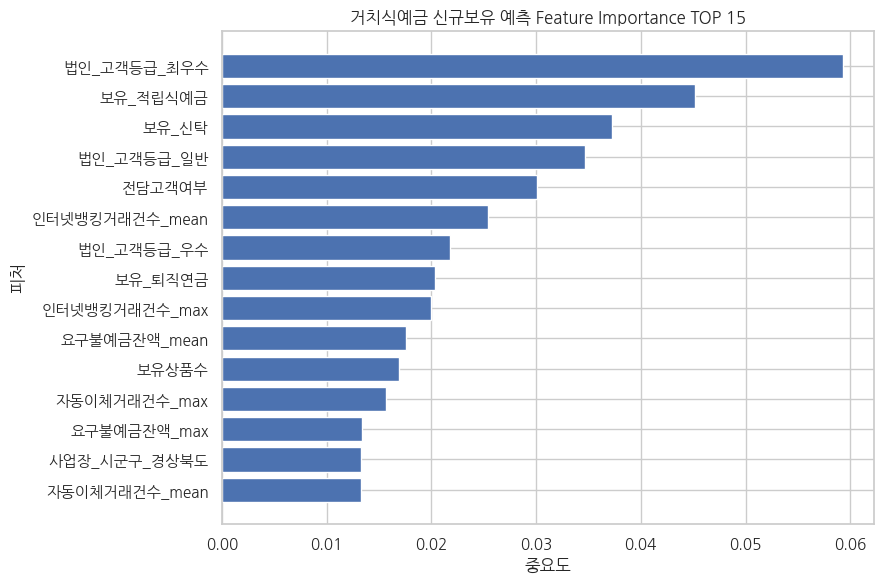

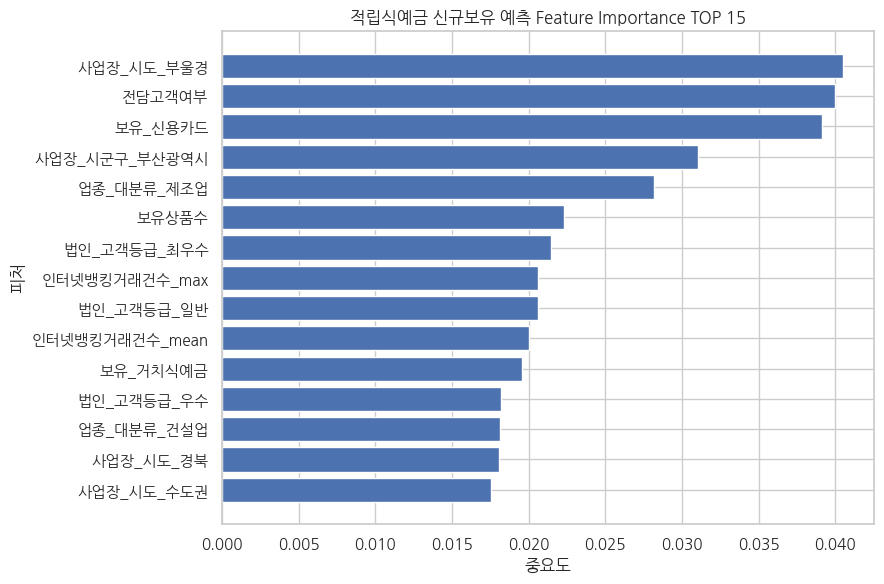

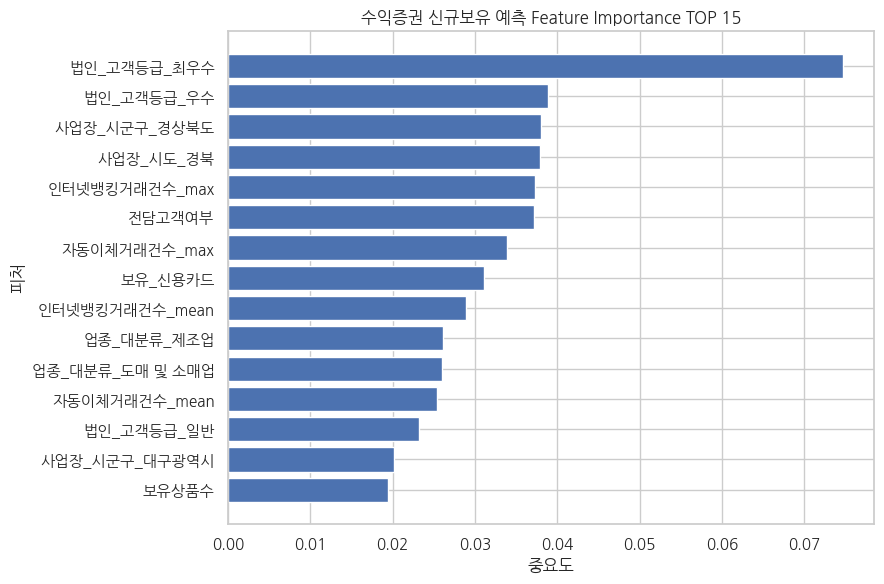

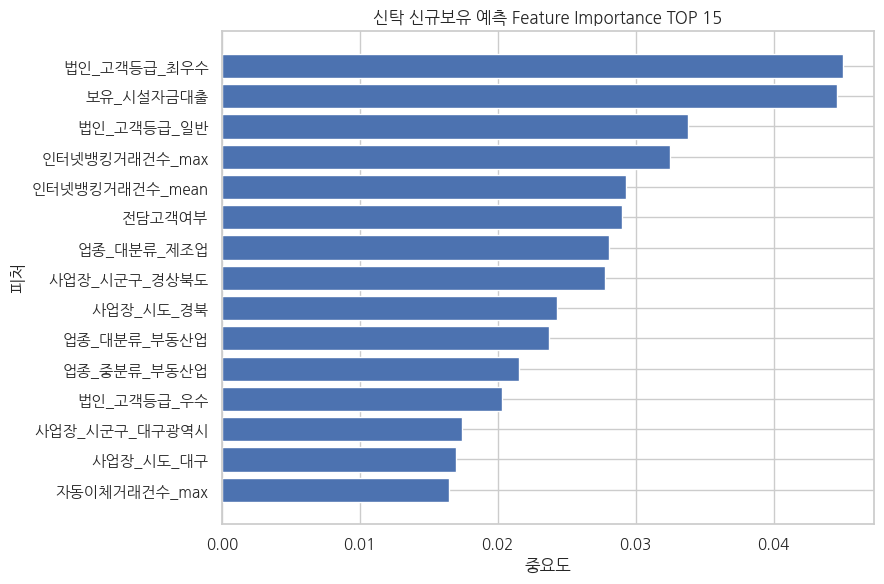

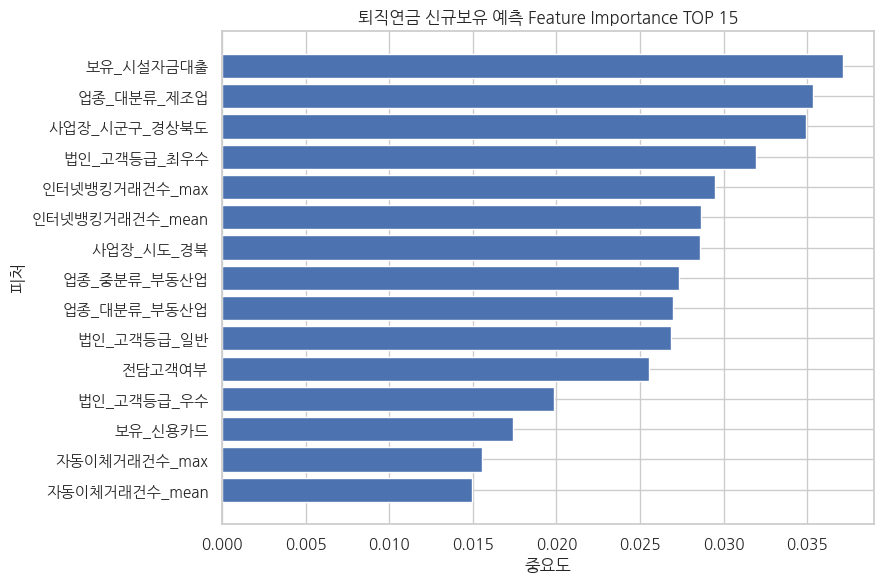

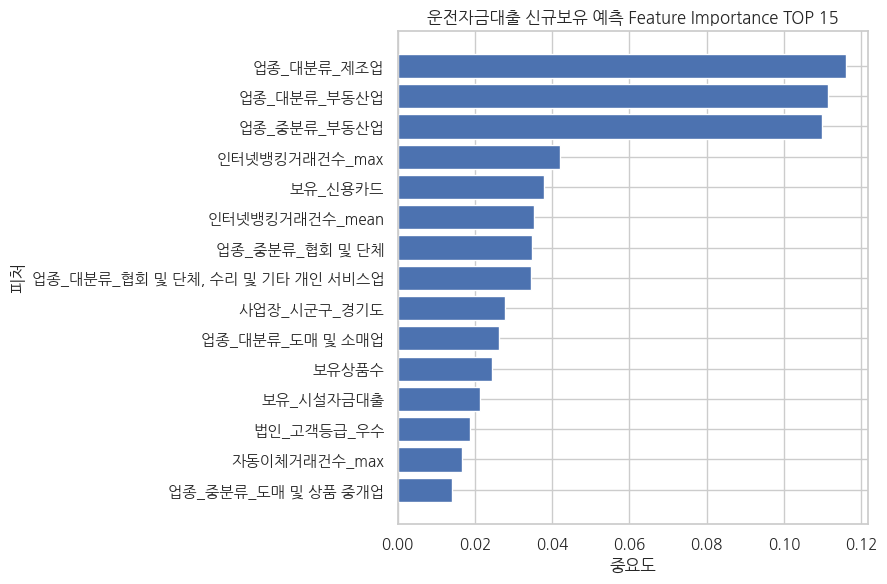

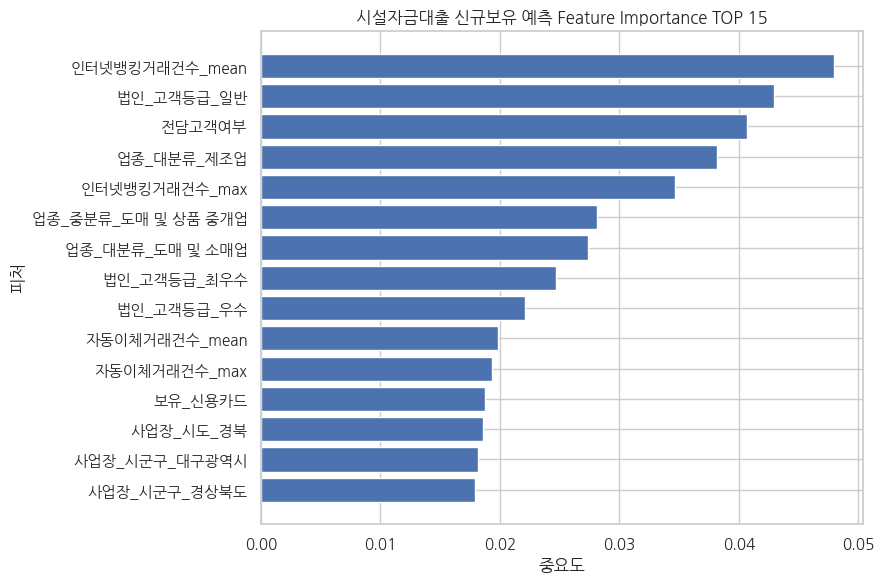

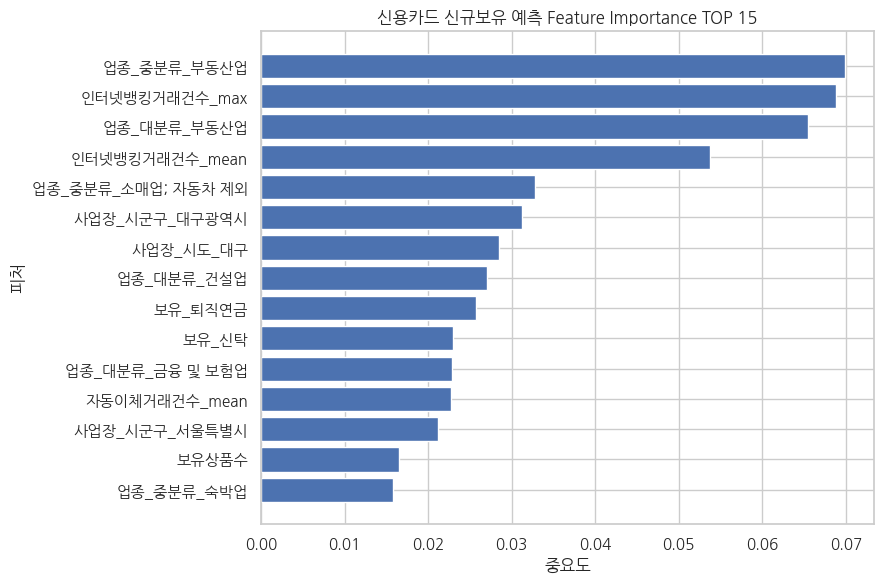

In [61]:
# ============================================================
# [실험] 상품별 Feature Importance 시각화
# - 상품별 TOP 15 중요 피처 막대그래프
# ============================================================

PLOT_TOP_N = 15

if product_importance_df.empty:
    print("product_importance_df가 비어 있음. 먼저 상품별 FI 산출 셀을 실행해야 함.")
else:
    completed_products = (
        product_model_summary_df
        .query("상태 == '산출완료'")["상품군"]
        .tolist()
    )

    for item in completed_products:
        plot_df = (
            product_importance_df
            .query("상품군 == @item")
            .sort_values("중요도", ascending=False)
            .head(PLOT_TOP_N)
            .sort_values("중요도", ascending=True)
        )

        plt.figure(figsize=(9, 6))
        plt.barh(plot_df["피처"], plot_df["중요도"])
        plt.title(f"{item} 신규보유 예측 Feature Importance TOP {PLOT_TOP_N}")
        plt.xlabel("중요도")
        plt.ylabel("피처")
        plt.tight_layout()
        plt.show()

[전체 상품 기준 피처 그룹 중요도]


,피처그룹,중요도합,평균중요도,피처수,등장상품수,중요도비중(%)
0,업종,2.168736,0.003476,78,8,27.109199
1,거래 활동성,1.455470,0.005685,32,8,18.193373
2,지역,1.150169,0.007189,20,8,14.377117
3,상품 보유 이력,0.904710,0.011309,10,8,11.308869
4,여신/대출 규모,0.891916,0.001922,58,8,11.148955
5,고객등급/전담,0.874974,0.027343,4,8,10.937171
6,예금/투자 규모,0.376024,0.001958,24,8,4.700295
7,카드/결제,0.171963,0.003583,6,8,2.149532
8,외환,0.006039,0.000189,4,8,0.075489


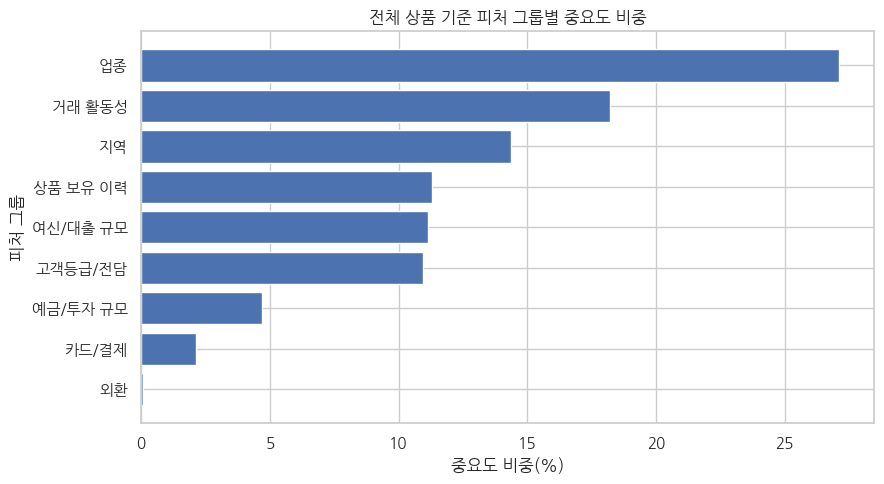

[상품별 피처 그룹 중요도]


,상품군,피처그룹,중요도합,평균중요도,피처수,상품별중요도비중(%)
0,거치식예금,거래 활동성,0.182793,0.005712,32,18.279348
1,거치식예금,업종,0.163174,0.002092,78,16.317445
2,거치식예금,상품 보유 이력,0.149478,0.014948,10,14.947818
3,거치식예금,고객등급/전담,0.145804,0.036451,4,14.580426
4,거치식예금,여신/대출 규모,0.134217,0.002314,58,13.421682
5,거치식예금,지역,0.105698,0.005285,20,10.569849
6,거치식예금,예금/투자 규모,0.091866,0.003828,24,9.186590
7,거치식예금,카드/결제,0.025624,0.004271,6,2.562413
8,거치식예금,외환,0.001344,0.000336,4,0.134429
9,수익증권,업종,0.193564,0.002482,78,19.356392


[상품별 피처 그룹 중요도 Pivot]


피처그룹,상품 보유 이력,예금/투자 규모,여신/대출 규모,거래 활동성,카드/결제,고객등급/전담,업종,지역,외환
상품군,,,,,,,,,
거치식예금,14.95,9.19,13.42,18.28,2.56,14.58,16.32,10.57,0.13
수익증권,12.97,4.11,10.70,16.97,1.65,17.41,19.36,16.81,0.03
시설자금대출,8.49,5.80,9.42,19.92,2.74,13.04,27.49,13.05,0.05
신용카드,10.60,4.46,8.10,21.10,0.00,3.99,36.87,14.88,0.00
신탁,8.94,4.05,14.75,19.51,2.79,12.81,22.35,14.71,0.09
운전자금대출,11.08,1.59,7.36,15.91,1.63,5.23,48.12,8.98,0.10
적립식예금,14.06,5.16,12.85,15.94,2.55,10.02,19.30,19.96,0.15
퇴직연금,9.39,3.25,12.59,17.91,3.27,10.41,27.07,16.06,0.04


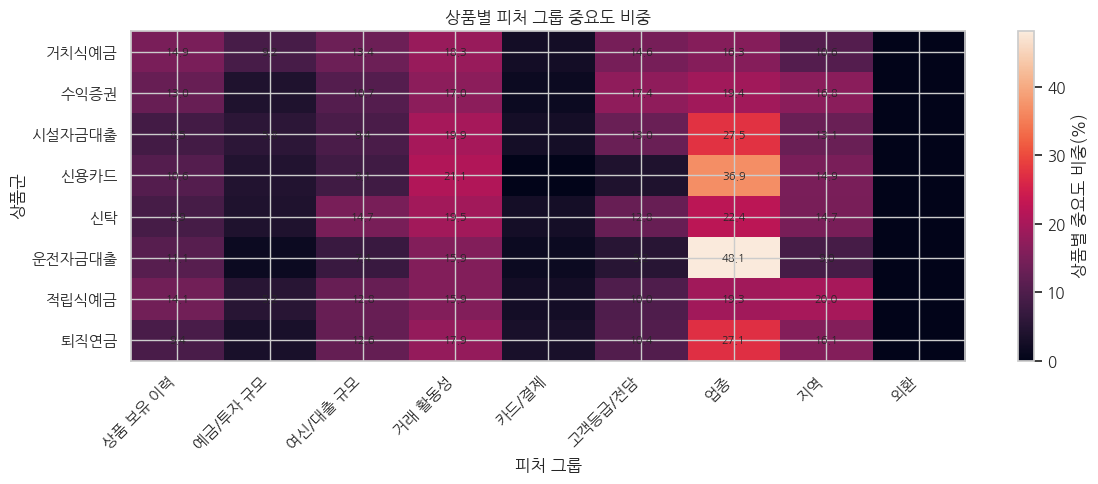

[상품별 TOP3 피처 그룹]


,상품군,피처그룹,중요도합,평균중요도,피처수,상품별중요도비중(%)
0,거치식예금,거래 활동성,0.182793,0.005712,32,18.279348
1,거치식예금,업종,0.163174,0.002092,78,16.317445
2,거치식예금,상품 보유 이력,0.149478,0.014948,10,14.947818
3,수익증권,업종,0.193564,0.002482,78,19.356392
4,수익증권,고객등급/전담,0.174071,0.043518,4,17.407090
5,수익증권,거래 활동성,0.169743,0.005304,32,16.974320
6,시설자금대출,업종,0.274902,0.003524,78,27.490248
7,시설자금대출,거래 활동성,0.199188,0.006225,32,19.918759
8,시설자금대출,지역,0.130509,0.006525,20,13.050867
9,신용카드,업종,0.368662,0.004726,78,36.866218


In [62]:
# ============================================================
# [해석] 피처 그룹별 Feature Importance 집계 및 시각화
# - 개별 피처 255개를 그대로 해석하지 않고
# - 상품보유이력 / 예금 / 여신 / 거래활동 / 고객속성 / 업종 / 지역 등으로 묶어서 해석
# - product_importance_df 필요
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. 확인
# ------------------------------------------------------------

if "product_importance_df" not in globals():
    raise NameError("product_importance_df가 없습니다. 먼저 상품별 Feature Importance 산출 셀을 실행하세요.")

# ------------------------------------------------------------
# 1. 피처명을 그룹으로 분류하는 함수
# ------------------------------------------------------------

def classify_feature_group(feature_name):
    f = str(feature_name)

    # 상품 보유 여부
    if f.startswith("보유_") or f == "보유상품수":
        return "상품 보유 이력"

    # 업종
    if f.startswith("업종_"):
        return "업종"

    # 지역
    if f.startswith("사업장_"):
        return "지역"

    # 고객 속성
    if f.startswith("법인_고객등급") or f.startswith("전담고객여부"):
        return "고객등급/전담"

    # 예금 / 투자 / 수신성 상품
    if any(k in f for k in [
        "요구불예금",
        "거치식예금",
        "적립식예금",
        "수익증권",
        "신탁",
        "퇴직연금"
    ]):
        return "예금/투자 규모"

    # 여신 / 대출
    if any(k in f for k in [
        "여신",
        "운전_",
        "시설_",
        "대출",
        "한도"
    ]):
        return "여신/대출 규모"

    # 카드
    if any(k in f for k in [
        "신용카드",
        "체크카드",
        "카드"
    ]):
        return "카드/결제"

    # 거래 채널 / 활동성
    if any(k in f for k in [
        "인터넷뱅킹",
        "스마트뱅킹",
        "폰뱅킹",
        "ATM",
        "창구",
        "자동이체",
        "입금",
        "출금",
        "거래금액",
        "거래건수"
    ]):
        return "거래 활동성"

    # 외환
    if "외환" in f or "수출" in f or "수입" in f:
        return "외환"

    return "기타"


# ------------------------------------------------------------
# 2. 그룹 컬럼 생성
# ------------------------------------------------------------

group_importance_df = product_importance_df.copy()
group_importance_df["피처그룹"] = group_importance_df["피처"].apply(classify_feature_group)

# ------------------------------------------------------------
# 3. 전체 상품 평균 기준 그룹 중요도
# - 상품별 중요도를 모두 모아서 그룹 단위로 합산
# ------------------------------------------------------------

group_summary_all = (
    group_importance_df
    .groupby("피처그룹")
    .agg(
        중요도합=("중요도", "sum"),
        평균중요도=("중요도", "mean"),
        피처수=("피처", "nunique"),
        등장상품수=("상품군", "nunique")
    )
    .reset_index()
)

group_summary_all["중요도비중(%)"] = (
    group_summary_all["중요도합"] / group_summary_all["중요도합"].sum() * 100
)

group_summary_all = (
    group_summary_all
    .sort_values("중요도합", ascending=False)
    .reset_index(drop=True)
)

print("[전체 상품 기준 피처 그룹 중요도]")
display(group_summary_all)

# ------------------------------------------------------------
# 4. 전체 그룹 중요도 시각화
# ------------------------------------------------------------

plot_df = group_summary_all.sort_values("중요도합", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["피처그룹"], plot_df["중요도비중(%)"])
plt.title("전체 상품 기준 피처 그룹별 중요도 비중")
plt.xlabel("중요도 비중(%)")
plt.ylabel("피처 그룹")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. 상품별 그룹 중요도 집계
# ------------------------------------------------------------

group_summary_by_product = (
    group_importance_df
    .groupby(["상품군", "피처그룹"])
    .agg(
        중요도합=("중요도", "sum"),
        평균중요도=("중요도", "mean"),
        피처수=("피처", "nunique")
    )
    .reset_index()
)

# 상품별 내부 비중 계산
group_summary_by_product["상품별중요도비중(%)"] = (
    group_summary_by_product
    .groupby("상품군")["중요도합"]
    .transform(lambda x: x / x.sum() * 100)
)

group_summary_by_product = (
    group_summary_by_product
    .sort_values(["상품군", "상품별중요도비중(%)"], ascending=[True, False])
    .reset_index(drop=True)
)

print("[상품별 피처 그룹 중요도]")
display(group_summary_by_product)


# ------------------------------------------------------------
# 6. 상품별 그룹 중요도 Pivot
# - 발표용 표/히트맵으로 쓰기 좋음
# ------------------------------------------------------------

group_pivot = (
    group_summary_by_product
    .pivot_table(
        index="상품군",
        columns="피처그룹",
        values="상품별중요도비중(%)",
        fill_value=0
    )
)

# 보기 좋은 컬럼 순서
preferred_order = [
    "상품 보유 이력",
    "예금/투자 규모",
    "여신/대출 규모",
    "거래 활동성",
    "카드/결제",
    "고객등급/전담",
    "업종",
    "지역",
    "외환",
    "기타"
]

ordered_cols = [c for c in preferred_order if c in group_pivot.columns]
group_pivot = group_pivot[ordered_cols]

print("[상품별 피처 그룹 중요도 Pivot]")
display(group_pivot.round(2))


# ------------------------------------------------------------
# 7. 상품별 그룹 중요도 히트맵
# - seaborn 없어도 matplotlib으로 그림
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

data = group_pivot.values
plt.imshow(data, aspect="auto")

plt.colorbar(label="상품별 중요도 비중(%)")
plt.xticks(
    ticks=np.arange(len(group_pivot.columns)),
    labels=group_pivot.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(group_pivot.index)),
    labels=group_pivot.index
)

plt.title("상품별 피처 그룹 중요도 비중")
plt.xlabel("피처 그룹")
plt.ylabel("상품군")

# 값 표시
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        value = data[i, j]
        if value >= 5:
            plt.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. 상품별 TOP 그룹 요약
# ------------------------------------------------------------

top_group_by_product = (
    group_summary_by_product
    .sort_values(["상품군", "상품별중요도비중(%)"], ascending=[True, False])
    .groupby("상품군")
    .head(3)
    .reset_index(drop=True)
)

print("[상품별 TOP3 피처 그룹]")
display(top_group_by_product)

In [63]:
# ============================================================
# 피처셋별 성능 비교
# - 네 노트북 구조 기준
# - 2023 피처 -> 2024 신규보유 학습
# - Feature Importance 기반 피처셋 생성
# - 2024 피처 -> 2025 신규보유 예측
# - ExtraTrees + Item-CF Hybrid 5:5 기준 성능 비교
#
# 중요:
# - 기존 모델비교 셀과 조건을 맞추기 위해 별도 mask_already_held는 사용하지 않음
# - 기존 보유상품 제외는 evaluate_score_matrix 함수 내부 로직에 맡김
# - ExtraTrees 파라미터는 기존 모델비교 셀에서 사용한 값과 동일하게 고정
# ============================================================

import numpy as np
import pandas as pd
import copy

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier


# ------------------------------------------------------------
# 1. 선행 변수 확인
# ------------------------------------------------------------

required_variables = [
    "feat_2023",
    "feat_2024",
    "matrix_2023",
    "matrix_2024",
    "new_item_train",
    "new_item_test",
    "final_eval_users",
    "score_cf",
    "evaluate_score_matrix"
]

missing_variables = [
    v for v in required_variables
    if v not in globals()
]

if missing_variables:
    raise NameError(
        "피처셋 실험 전에 필요한 변수가 없습니다. "
        f"없는 변수: {missing_variables}"
    )


# ------------------------------------------------------------
# 2. 기본 설정
# ------------------------------------------------------------

K_EVAL = 3
MIN_POSITIVE = 10
ALPHA_CF = 0.5
ALPHA_ML = 0.5

products = matrix_2024.columns.tolist()

# 기존 모델비교 셀에서 ExtraTrees Hybrid NDCG@3 = 0.712897 나온 파라미터
EXTRA_PARAMS_FOR_FEATURE_TEST = {
    "n_estimators": 441,
    "max_depth": 27,
    "min_samples_leaf": 21,
    "min_samples_split": 23,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}


# ------------------------------------------------------------
# 3. 학습/예측 데이터 정렬
# ------------------------------------------------------------

train_users = (
    feat_2023.index
    .intersection(new_item_train.index)
    .intersection(matrix_2023.index)
)

test_users = (
    feat_2024.index
    .intersection(matrix_2024.index)
)

X_train_all = feat_2023.loc[train_users].copy()
X_test_all = feat_2024.loc[test_users].copy()

# 2023/2024 피처 컬럼 맞추기
common_features = X_train_all.columns.intersection(X_test_all.columns).tolist()

X_train_all = X_train_all[common_features].copy()
X_test_all = X_test_all[common_features].copy()

print("학습 고객 수:", len(train_users))
print("예측 고객 수:", len(test_users))
print("전체 피처 수:", len(common_features))


# ------------------------------------------------------------
# 4. row-wise min-max 정규화 함수
# - 기존 모델비교 셀과 같은 방식으로 고객별 상품점수 스케일 조정
# ------------------------------------------------------------

def minmax_row_safe(df):
    a = df.values.astype(float)

    mn = np.nanmin(a, axis=1, keepdims=True)
    mx = np.nanmax(a, axis=1, keepdims=True)
    d = mx - mn

    out = np.zeros_like(a, dtype=float)
    np.divide(a - mn, d, out=out, where=(d != 0))

    return pd.DataFrame(out, index=df.index, columns=df.columns)


# ------------------------------------------------------------
# 5. 2023 -> 2024 기준 Feature Importance 계산
# - 상품별 ExtraTrees 중요도를 평균
# ------------------------------------------------------------

fi_records = []

for item in products:
    at_risk_users = matrix_2023.loc[train_users].index[
        matrix_2023.loc[train_users, item] == 0
    ]

    X_item = X_train_all.loc[at_risk_users]
    y_item = new_item_train.loc[at_risk_users, item].fillna(0).astype(int)

    pos = int(y_item.sum())
    neg = int((y_item == 0).sum())

    print(f"[FI 계산] {item} | 양성 {pos} / 음성 {neg}")

    if y_item.nunique() < 2 or pos < MIN_POSITIVE:
        print(f" -> {item}: 양성 샘플 부족으로 FI 계산 제외")
        continue

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(**EXTRA_PARAMS_FOR_FEATURE_TEST))
    ])

    model.fit(X_item, y_item)

    importances = model.named_steps["model"].feature_importances_

    for feature, importance in zip(common_features, importances):
        fi_records.append({
            "상품군": item,
            "피처": feature,
            "중요도": importance
        })

    del model


feature_importance_detail = pd.DataFrame(fi_records)

if len(feature_importance_detail) == 0:
    raise ValueError("Feature Importance 계산 결과가 비어 있습니다.")

global_importance = (
    feature_importance_detail
    .groupby("피처", as_index=False)["중요도"]
    .mean()
)

# 중요도 없는 피처는 0으로 채움
global_importance = (
    pd.DataFrame({"피처": common_features})
    .merge(global_importance, on="피처", how="left")
    .fillna({"중요도": 0})
    .sort_values("중요도", ascending=False)
    .reset_index(drop=True)
)

importance_sum = global_importance["중요도"].sum()

if importance_sum <= 0:
    raise ValueError("Feature Importance 합계가 0입니다.")

global_importance["중요도비중"] = global_importance["중요도"] / importance_sum
global_importance["누적중요도비중"] = global_importance["중요도비중"].cumsum()

print("\n[전체 Feature Importance TOP 30]")
display(global_importance.head(30))


# ------------------------------------------------------------
# 6. 피처 선택 함수
# ------------------------------------------------------------

def select_features(rule):
    if rule == "TOP30":
        return global_importance["피처"].head(30).tolist()

    elif rule == "TOP50":
        return global_importance["피처"].head(50).tolist()

    elif rule == "TOP100":
        return global_importance["피처"].head(100).tolist()

    elif rule in ["FI70", "FI80", "FI90"]:
        threshold = {
            "FI70": 0.70,
            "FI80": 0.80,
            "FI90": 0.90
        }[rule]

        selected_count = int(
            np.searchsorted(
                global_importance["누적중요도비중"].to_numpy(),
                threshold,
                side="left"
            ) + 1
        )

        selected_count = min(selected_count, len(global_importance))

        return global_importance["피처"].head(selected_count).tolist()

    elif rule == "ALL":
        return common_features.copy()

    else:
        raise ValueError(f"알 수 없는 피처셋 규칙: {rule}")


# ------------------------------------------------------------
# 7. 피처셋별 ML 점수 생성 함수
# ------------------------------------------------------------

def build_ml_score_for_features(selected_features):
    score_ml = pd.DataFrame(
        0.0,
        index=test_users,
        columns=products
    )

    X_train = X_train_all[selected_features].copy()
    X_test = X_test_all[selected_features].copy()

    for item in products:
        at_risk_users = matrix_2023.loc[train_users].index[
            matrix_2023.loc[train_users, item] == 0
        ]

        X_item = X_train.loc[at_risk_users]
        y_item = new_item_train.loc[at_risk_users, item].fillna(0).astype(int)

        pos = int(y_item.sum())

        if y_item.nunique() < 2 or pos < MIN_POSITIVE:
            score_ml[item] = float(y_item.mean()) if len(y_item) > 0 else 0
            continue

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(**EXTRA_PARAMS_FOR_FEATURE_TEST))
        ])

        model.fit(X_item, y_item)
        score_ml[item] = model.predict_proba(X_test)[:, 1]

        del model

    return score_ml


# ------------------------------------------------------------
# 8. 피처셋별 성능 비교
# ------------------------------------------------------------

FEATURE_RULES = [
    "TOP30",
    "TOP50",
    "TOP100",
    "FI70",
    "FI80",
    "FI90",
    "ALL"
]

feature_set_records = []

# 기존 모델비교 셀과 동일하게 CF는 정규화만 수행
# 보유상품 제외는 evaluate_score_matrix 내부에서 처리
cf_score_eval = score_cf.reindex(index=test_users, columns=products).fillna(0)
cf_score_norm = minmax_row_safe(cf_score_eval)

for rule in FEATURE_RULES:
    selected_features = select_features(rule)

    print("\n" + "=" * 70)
    print(f"[피처셋 실험] {rule} | 피처 수: {len(selected_features)}")
    print("=" * 70)

    score_ml = build_ml_score_for_features(selected_features)

    # 기존 모델비교 셀과 동일하게 ML도 정규화만 수행
    ml_score_norm = minmax_row_safe(score_ml)

    hybrid_score = (
        ALPHA_CF * cf_score_norm
        + ALPHA_ML * ml_score_norm
    )

    metrics = evaluate_score_matrix(
        score_df=hybrid_score,
        base_matrix=matrix_2024,
        new_item=new_item_test,
        users=final_eval_users,
        k=K_EVAL
    )

    feature_set_records.append({
        "피처셋": rule,
        "피처수": len(selected_features),
        "Hybrid_NDCG@3": metrics["NDCG"],
        "Hybrid_MAP@3": metrics["MAP"],
        "Hybrid_HitRate@3": metrics["HitRate"],
        "Hybrid_Precision@3": metrics["Precision"],
        "Hybrid_Recall@3": metrics["Recall"]
    })


# ------------------------------------------------------------
# 9. 결과 출력
# ------------------------------------------------------------

feature_set_results = (
    pd.DataFrame(feature_set_records)
    .sort_values(
        ["Hybrid_NDCG@3", "Hybrid_MAP@3", "Hybrid_HitRate@3"],
        ascending=False
    )
    .reset_index(drop=True)
)

BEST_FEATURE_RULE = feature_set_results.iloc[0]["피처셋"]

display(
    feature_set_results
    .style
    .format({
        "Hybrid_NDCG@3": "{:.6f}",
        "Hybrid_MAP@3": "{:.6f}",
        "Hybrid_HitRate@3": "{:.6f}",
        "Hybrid_Precision@3": "{:.6f}",
        "Hybrid_Recall@3": "{:.6f}"
    })
    .highlight_max(
        subset=[
            "Hybrid_NDCG@3",
            "Hybrid_MAP@3",
            "Hybrid_HitRate@3"
        ],
        color="#fff59d"
    )
)

print("\n선택된 최적 피처셋:", BEST_FEATURE_RULE)
print("최적 Hybrid NDCG@3:", round(feature_set_results.iloc[0]["Hybrid_NDCG@3"], 6))

print("\n생성 변수:")
print("- feature_importance_detail")
print("- global_importance")
print("- feature_set_results")
print("- BEST_FEATURE_RULE")

학습 고객 수: 10567
예측 고객 수: 12364
전체 피처 수: 236
[FI 계산] 요구불예금 | 양성 3 / 음성 62
 -> 요구불예금: 양성 샘플 부족으로 FI 계산 제외
[FI 계산] 거치식예금 | 양성 127 / 음성 9640


[FI 계산] 적립식예금 | 양성 104 / 음성 9719
[FI 계산] 수익증권 | 양성 15 / 음성 10322
[FI 계산] 신탁 | 양성 139 / 음성 7916
[FI 계산] 퇴직연금 | 양성 110 / 음성 8220
[FI 계산] 운전자금대출 | 양성 93 / 음성 1289
[FI 계산] 시설자금대출 | 양성 91 / 음성 6996
[FI 계산] 신용카드 | 양성 116 / 음성 2164

[전체 Feature Importance TOP 30]


,피처,중요도,중요도비중,누적중요도비중
0,업종_대분류_제조업,0.037213,0.037213,0.037213
1,인터넷뱅킹거래건수_max,0.035675,0.035675,0.072888
2,법인_고객등급_최우수,0.035023,0.035023,0.107911
3,인터넷뱅킹거래건수_mean,0.033668,0.033668,0.141578
4,업종_대분류_부동산업,0.032097,0.032097,0.173675
5,업종_중분류_부동산업,0.032024,0.032024,0.205699
6,전담고객여부,0.028403,0.028403,0.234102
7,법인_고객등급_일반,0.024501,0.024501,0.258603
8,법인_고객등급_우수,0.021445,0.021445,0.280048
9,보유_신용카드,0.020742,0.020742,0.300790



[피처셋 실험] TOP30 | 피처 수: 30

[피처셋 실험] TOP50 | 피처 수: 50

[피처셋 실험] TOP100 | 피처 수: 100

[피처셋 실험] FI70 | 피처 수: 45

[피처셋 실험] FI80 | 피처 수: 63

[피처셋 실험] FI90 | 피처 수: 91

[피처셋 실험] ALL | 피처 수: 236


,피처셋,피처수,Hybrid_NDCG@3,Hybrid_MAP@3,Hybrid_HitRate@3,Hybrid_Precision@3,Hybrid_Recall@3
0,ALL,236,0.712897,0.657053,0.886677,0.356815,0.847626
1,TOP50,50,0.712543,0.657946,0.885145,0.355283,0.842777
2,FI90,91,0.711866,0.657989,0.879020,0.354773,0.840480
3,FI70,45,0.711317,0.657819,0.879020,0.354262,0.840097
4,FI80,63,0.707471,0.653905,0.875957,0.353752,0.835758
5,TOP100,100,0.706781,0.651268,0.880551,0.353241,0.838693
6,TOP30,30,0.699173,0.646376,0.868300,0.350179,0.826697



선택된 최적 피처셋: ALL
최적 Hybrid NDCG@3: 0.712897

생성 변수:
- feature_importance_detail
- global_importance
- feature_set_results
- BEST_FEATURE_RULE


In [67]:
# ============================================================
#   최종모델생성
# - 튜닝: 2023→2024 내부 8:2
# - 최종 학습: 2023 전체 피처 -> 2024 신규보유
# - 최종 평가: 2024 피처 -> 2025 신규보유
# - 피처셋: ALL
# - Hybrid = Item-CF 50% + ML 50%
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics.pairwise import cosine_similarity


# ------------------------------------------------------------
# 1. Optuna Best Params 고정
# ------------------------------------------------------------

BEST_ET_PARAMS = {
    "n_estimators": 573,
    "max_depth": 33,
    "min_samples_leaf": 30,
    "min_samples_split": 43,
    "max_features": 0.3,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

K_EVAL = 3
MIN_POSITIVE = 10
ALPHA_CF = 0.5
ALPHA_ML = 0.5

products = matrix_2024.columns.tolist()


# ------------------------------------------------------------
# 2. 최종 학습/예측 고객 및 피처 정렬
# ------------------------------------------------------------

train_users_final = (
    feat_2023.index
    .intersection(matrix_2023.index)
    .intersection(new_item_train.index)
)

predict_users_final = (
    feat_2024.index
    .intersection(matrix_2024.index)
)

final_test_users = (
    final_eval_users
    .intersection(predict_users_final)
    .intersection(new_item_test.index)
)

X_train_final = feat_2023.loc[train_users_final].copy()
X_predict_final = feat_2024.loc[predict_users_final].copy()

final_features = X_train_final.columns.intersection(X_predict_final.columns).tolist()

X_train_final = X_train_final[final_features].copy()
X_predict_final = X_predict_final[final_features].copy()

print("최종 모델: ExtraTrees + Item-CF Hybrid")
print("최종 파라미터:", BEST_ET_PARAMS)
print("피처셋: ALL")
print("사용 피처 수:", len(final_features))
print("최종 학습 고객 수:", len(train_users_final))
print("최종 예측 고객 수:", len(predict_users_final))
print("최종 평가 고객 수:", len(final_test_users))


# ------------------------------------------------------------
# 3. row-wise min-max 정규화 함수
# ------------------------------------------------------------

def minmax_row_safe(df):
    a = df.values.astype(float)

    mn = np.nanmin(a, axis=1, keepdims=True)
    mx = np.nanmax(a, axis=1, keepdims=True)
    d = mx - mn

    out = np.zeros_like(a, dtype=float)
    np.divide(a - mn, d, out=out, where=(d != 0))

    return pd.DataFrame(out, index=df.index, columns=df.columns)


# ------------------------------------------------------------
# 4. 상품별 ExtraTrees 최종 학습 후 ML 점수 생성
# ------------------------------------------------------------

final_ml_score = pd.DataFrame(
    0.0,
    index=predict_users_final,
    columns=products
)

final_model_info = []

base_train_final = matrix_2023.loc[train_users_final, products]
y_train_final = new_item_train.loc[train_users_final, products]

for item in products:
    # 2023년에 해당 상품을 미보유한 고객만 학습 대상
    at_risk_users = base_train_final.index[
        base_train_final[item] == 0
    ]

    X_item = X_train_final.loc[at_risk_users]
    y_item = y_train_final.loc[at_risk_users, item].fillna(0).astype(int)

    pos = int(y_item.sum())
    neg = int((y_item == 0).sum())

    print(f"[{item}] 학습고객수={len(y_item)} | 양성={pos} | 음성={neg}")

    # 양성 샘플 부족 시 fallback
    if y_item.nunique() < 2 or pos < MIN_POSITIVE:
        final_ml_score[item] = float(y_item.mean()) if len(y_item) > 0 else 0.0

        final_model_info.append({
            "상품군": item,
            "학습방식": "fallback_mean",
            "학습고객수": len(y_item),
            "양성수": pos,
            "음성수": neg
        })
        continue

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(**BEST_ET_PARAMS))
    ])

    model.fit(X_item, y_item)
    final_ml_score[item] = model.predict_proba(X_predict_final)[:, 1]

    final_model_info.append({
        "상품군": item,
        "학습방식": "ExtraTrees",
        "학습고객수": len(y_item),
        "양성수": pos,
        "음성수": neg
    })

final_model_info = pd.DataFrame(final_model_info)


# ------------------------------------------------------------
# 5. 최종 Item-CF 점수 생성
# - 2024년 보유상품 패턴 기준
# ------------------------------------------------------------

item_sim_final = pd.DataFrame(
    cosine_similarity(matrix_2024.loc[predict_users_final, products].T),
    index=products,
    columns=products
)

np.fill_diagonal(item_sim_final.values, 0)

final_cf_score = matrix_2024.loc[predict_users_final, products].dot(item_sim_final)


# ------------------------------------------------------------
# 6. CF / ML 점수 정규화 후 Hybrid 점수 생성
# ------------------------------------------------------------

final_cf_score_norm = minmax_row_safe(final_cf_score)
final_ml_score_norm = minmax_row_safe(final_ml_score)

final_hybrid_score = (
    ALPHA_CF * final_cf_score_norm
    + ALPHA_ML * final_ml_score_norm
)


# ------------------------------------------------------------
# 7. 최종 테스트 성능 평가
# - evaluate_score_matrix 내부에서 기존 보유상품 제외
# ------------------------------------------------------------

final_metrics = evaluate_score_matrix(
    score_df=final_hybrid_score,
    base_matrix=matrix_2024,
    new_item=new_item_test,
    users=final_test_users,
    k=K_EVAL
)

final_result = pd.DataFrame([{
    "구분": "2024→2025 최종 테스트",
    "모델": "ExtraTrees + Item-CF Hybrid",
    "피처셋": "ALL",
    "결합방식": "CF 50% + ML 50%",
    "K": K_EVAL,
    "NDCG@3": final_metrics["NDCG"],
    "MAP@3": final_metrics["MAP"],
    "HitRate@3": final_metrics["HitRate"],
    "Precision@3": final_metrics["Precision"],
    "Recall@3": final_metrics["Recall"],
    "평가고객수": final_metrics.get("평가고객수", len(final_test_users))
}])


# ------------------------------------------------------------
# 8. 출력
# ------------------------------------------------------------

print("\n[최종 테스트 성능]")
display(
    final_result
    .style
    .format({
        "NDCG@3": "{:.6f}",
        "MAP@3": "{:.6f}",
        "HitRate@3": "{:.6f}",
        "Precision@3": "{:.6f}",
        "Recall@3": "{:.6f}"
    })
)

print("\n[상품별 최종 학습 정보]")
display(final_model_info)

print("\n생성 변수:")
print("- BEST_ET_PARAMS")
print("- final_ml_score")
print("- final_cf_score")
print("- final_hybrid_score")
print("- final_result")
print("- final_model_info")
print("- final_features")

최종 모델: ExtraTrees + Item-CF Hybrid
최종 파라미터: {'n_estimators': 573, 'max_depth': 33, 'min_samples_leaf': 30, 'min_samples_split': 43, 'max_features': 0.3, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
피처셋: ALL
사용 피처 수: 236
최종 학습 고객 수: 10567
최종 예측 고객 수: 12364
최종 평가 고객 수: 653
[요구불예금] 학습고객수=65 | 양성=3 | 음성=62
[거치식예금] 학습고객수=9767 | 양성=127 | 음성=9640
[적립식예금] 학습고객수=9823 | 양성=104 | 음성=9719
[수익증권] 학습고객수=10337 | 양성=15 | 음성=10322
[신탁] 학습고객수=8055 | 양성=139 | 음성=7916
[퇴직연금] 학습고객수=8330 | 양성=110 | 음성=8220
[운전자금대출] 학습고객수=1382 | 양성=93 | 음성=1289
[시설자금대출] 학습고객수=7087 | 양성=91 | 음성=6996


[신용카드] 학습고객수=2280 | 양성=116 | 음성=2164

[최종 테스트 성능]


,구분,모델,피처셋,결합방식,K,NDCG@3,MAP@3,HitRate@3,Precision@3,Recall@3,평가고객수
0,2024→2025 최종 테스트,ExtraTrees + Item-CF Hybrid,ALL,CF 50% + ML 50%,3,0.716089,0.672877,0.845329,0.359877,0.821465,653



[상품별 최종 학습 정보]


,상품군,학습방식,학습고객수,양성수,음성수
0,요구불예금,fallback_mean,65,3,62
1,거치식예금,ExtraTrees,9767,127,9640
2,적립식예금,ExtraTrees,9823,104,9719
3,수익증권,ExtraTrees,10337,15,10322
4,신탁,ExtraTrees,8055,139,7916
5,퇴직연금,ExtraTrees,8330,110,8220
6,운전자금대출,ExtraTrees,1382,93,1289
7,시설자금대출,ExtraTrees,7087,91,6996
8,신용카드,ExtraTrees,2280,116,2164



생성 변수:
- BEST_ET_PARAMS
- final_ml_score
- final_cf_score
- final_hybrid_score
- final_result
- final_model_info
- final_features


In [ ]:
# ============================================================
# score_cf + score_ml 기반 최종 Hybrid 추천점수 생성
# - Hybrid = CF 50% + ML 50%
# - 2024년 이미 보유한 상품은 추천 제외
# - 평가 고객 기준 상품별 1순위 적중 Top3 법인 추출
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. 행 단위 min-max 정규화 함수
# ------------------------------------------------------------

def minmax_row_safe(df):
    arr = df.astype(float).values

    mn = np.nanmin(arr, axis=1, keepdims=True)
    mx = np.nanmax(arr, axis=1, keepdims=True)
    diff = mx - mn

    scaled = np.where(diff == 0, 0, (arr - mn) / diff)

    return pd.DataFrame(
        scaled,
        index=df.index,
        columns=df.columns
    )


# 2. score_cf / score_ml 정렬


common_users = score_cf.index.intersection(score_ml.index)
common_items = score_cf.columns.intersection(score_ml.columns)

score_cf_aligned = score_cf.loc[common_users, common_items].copy()
score_ml_aligned = score_ml.loc[common_users, common_items].copy()


# 3. 점수 정규화 후 5:5 Hybrid 생성


cf_n = minmax_row_safe(score_cf_aligned.fillna(0))
ml_n = minmax_row_safe(score_ml_aligned.fillna(0))

score_final = 0.5 * cf_n + 0.5 * ml_n

# ------------------------------------------------------------
# 4. 2024년에 이미 보유한 상품은 추천 제외
# ------------------------------------------------------------

hold_2024 = matrix_2024.reindex(score_final.index)[score_final.columns].fillna(0)

score_final_masked = score_final.mask(hold_2024 == 1, -np.inf)

print("score_final shape:", score_final.shape)
print("score_final_masked shape:", score_final_masked.shape)

# ------------------------------------------------------------
# 5. 평가 고객 지정
# - 2025년에 실제 신규보유 상품이 있는 고객
# - 최종 점수 행렬에도 존재해야 함
# ------------------------------------------------------------

eval_users = new_item_test.index[new_item_test.sum(axis=1) > 0]
eval_users = eval_users.intersection(score_final_masked.index)

score_eval = score_final_masked.loc[eval_users].copy()
actual_eval = new_item_test.loc[eval_users].copy()

common_items_eval = score_eval.columns.intersection(actual_eval.columns)
score_eval = score_eval[common_items_eval]
actual_eval = actual_eval[common_items_eval]

print("평가 고객 수:", len(eval_users))
print("평가 상품 수:", len(common_items_eval))

# ------------------------------------------------------------
# 6. 평가 고객별 Top3 추천 생성
# ------------------------------------------------------------

rows = []

for uid in score_eval.index:
    scores = score_eval.loc[uid].sort_values(ascending=False)

    actual_items = actual_eval.columns[
        actual_eval.loc[uid] == 1
    ].tolist()

    current_items = matrix_2024.columns[
        matrix_2024.reindex([uid]).fillna(0).iloc[0] == 1
    ].tolist()

    for rank, (item, score) in enumerate(scores.head(3).items(), start=1):
        if np.isneginf(score):
            continue

        rows.append({
            id_col: uid,
            "추천순위": rank,
            "추천상품군": item,
            "추천점수": score,
            "실제신규보유상품": ", ".join(actual_items),
            "현재보유상품": ", ".join(current_items),
            "적중여부": int(item in actual_items)
        })

recommendation_score_df = pd.DataFrame(rows)

display(recommendation_score_df.head(30))

print("추천 결과 행 수:", len(recommendation_score_df))
print("추천 대상 고객 수:", recommendation_score_df[id_col].nunique())

# ------------------------------------------------------------
# 7. 1순위 적중 고객만 추출
# ------------------------------------------------------------

top1_hit = recommendation_score_df[
    (recommendation_score_df["추천순위"] == 1) &
    (recommendation_score_df["적중여부"] == 1)
].copy()

print("\n1순위 적중 고객 수:", len(top1_hit))
print("1순위 적중률:", round(len(top1_hit) / len(eval_users) * 100, 2), "%")

# ------------------------------------------------------------
# 8. 상품별 추천점수 높은 순서 Top3 법인 추출
# ------------------------------------------------------------

top1_hit_top3_by_product = (
    top1_hit
    .sort_values(["추천상품군", "추천점수"], ascending=[True, False])
    .groupby("추천상품군")
    .head(3)
    .reset_index(drop=True)
)

display(top1_hit_top3_by_product)

print("\n상품별 1순위 적중 Top3 법인 수")
display(
    top1_hit_top3_by_product
    .groupby("추천상품군")[id_col]
    .count()
    .reset_index()
    .rename(columns={id_col: "법인수"})
)

score_final shape: (12364, 9)
score_final_masked shape: (12364, 9)
평가 고객 수: 653
평가 상품 수: 9


/tmp/ipykernel_371599/1732388305.py:22: RuntimeWarning: invalid value encountered in divide
  scaled = np.where(diff == 0, 0, (arr - mn) / diff)


,법인ID,추천순위,추천상품군,추천점수,실제신규보유상품,현재보유상품,적중여부
0,00a0049e060729db59e6f8e15bbc7e0f31b921e34f16299c90e83272dc06a34b,1,신용카드,0.506858,"시설자금대출, 신용카드","요구불예금, 운전자금대출",1
1,00a0049e060729db59e6f8e15bbc7e0f31b921e34f16299c90e83272dc06a34b,2,시설자금대출,0.324044,"시설자금대출, 신용카드","요구불예금, 운전자금대출",1
2,00a0049e060729db59e6f8e15bbc7e0f31b921e34f16299c90e83272dc06a34b,3,적립식예금,0.109209,"시설자금대출, 신용카드","요구불예금, 운전자금대출",0
3,00a7bf289f9a1af1512d833375119a996e6b6dce7e77400176d890eada367f38,1,운전자금대출,0.500000,적립식예금,"요구불예금, 신탁, 퇴직연금, 시설자금대출, 신용카드",0
4,00a7bf289f9a1af1512d833375119a996e6b6dce7e77400176d890eada367f38,2,수익증권,0.190127,적립식예금,"요구불예금, 신탁, 퇴직연금, 시설자금대출, 신용카드",0
5,00a7bf289f9a1af1512d833375119a996e6b6dce7e77400176d890eada367f38,3,거치식예금,0.179555,적립식예금,"요구불예금, 신탁, 퇴직연금, 시설자금대출, 신용카드",0
6,017f886c21c6d165148a88428f7d6124e226c188f2bb10db58e1c865cfe6c68f,1,시설자금대출,0.500001,거치식예금,"요구불예금, 신탁, 퇴직연금, 운전자금대출, 신용카드",0
7,017f886c21c6d165148a88428f7d6124e226c188f2bb10db58e1c865cfe6c68f,2,거치식예금,0.131565,거치식예금,"요구불예금, 신탁, 퇴직연금, 운전자금대출, 신용카드",1
8,017f886c21c6d165148a88428f7d6124e226c188f2bb10db58e1c865cfe6c68f,3,수익증권,0.113271,거치식예금,"요구불예금, 신탁, 퇴직연금, 운전자금대출, 신용카드",0
9,025b3448c92efc8caa594f460e7d9567e0f84e599ddb37fd93d5105fc0d3a885,1,시설자금대출,0.500001,적립식예금,"요구불예금, 운전자금대출, 신용카드",0


추천 결과 행 수: 1945
추천 대상 고객 수: 653

1순위 적중 고객 수: 339
1순위 적중률: 51.91 %


,법인ID,추천순위,추천상품군,추천점수,실제신규보유상품,현재보유상품,적중여부
0,b6794c03fa30a94b9c7eb97df3e17dd883abfd218629dee98eb90ed3271715c1,1,거치식예금,0.502716,거치식예금,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드",1
1,62e2642388cf7cece6b87962a211b9db6285e11f89b597e93e86480d9b23227a,1,거치식예금,0.502109,거치식예금,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드",1
2,5a0830d73c4a86eb20f3a374bd533b48c9eeffcdd216feb97e2e1172a26487c6,1,거치식예금,0.500443,거치식예금,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드",1
3,e5a7c95a6d4a507b4efe5e8942c0696c20b022e964aeb6e5cb79defea2182601,1,수익증권,0.299062,수익증권,"요구불예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드",1
4,36c0e62e6b7dca50d8a83b2f2a42d8cbcda20f76da2b47a0a6299101571680b1,1,시설자금대출,0.501271,시설자금대출,"요구불예금, 운전자금대출, 신용카드",1
5,282905135fbdf27b67b0b3a4c65143d202e75bbcf9c0dace3821d5c12fbb6f76,1,시설자금대출,0.500723,시설자금대출,"요구불예금, 운전자금대출, 신용카드",1
6,50adf7eba26a285d25c79c798dbb4cc3c2fcd9e86c0b36463ca6ef1b79db0f8c,1,시설자금대출,0.500630,"신탁, 퇴직연금, 시설자금대출","요구불예금, 운전자금대출, 신용카드",1
7,6d9fcdf45ee5a102b98803888a37cf991699354ae772b7ebcea26428af53b092,1,신용카드,0.937954,"시설자금대출, 신용카드","요구불예금, 운전자금대출",1
8,cb4ee59489f2c0947545e29f941e96d9fb6905264baccb8bf416022e5c80242d,1,신용카드,0.838657,신용카드,"요구불예금, 운전자금대출",1
9,b403e8a953c5d1ce08310922fe1917ee585552dca417e2a24277beb9886eb01f,1,신용카드,0.578114,신용카드,"요구불예금, 시설자금대출",1



상품별 1순위 적중 Top3 법인 수


,추천상품군,법인수
0,거치식예금,3
1,수익증권,1
2,시설자금대출,3
3,신용카드,3
4,신탁,3
5,요구불예금,3
6,운전자금대출,3
7,적립식예금,3
8,퇴직연금,3


In [36]:
# ============================================================
# 전체 점수 행렬 기준 상품별 추천점수 Top3 법인 추출
# - recommendation_score_df가 아니라 score_final_masked 사용
# - 각 상품별로 전체 법인 중 추천점수가 가장 높은 법인 3개 추출
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. 전체 최종 점수 행렬 long format 변환
# ------------------------------------------------------------

score_long = (
    score_final_masked
    .replace(-np.inf, np.nan)
    .reset_index()
    .rename(columns={score_final_masked.index.name or "index": id_col})
    .melt(
        id_vars=id_col,
        var_name="추천상품군",
        value_name="추천점수"
    )
)

# 추천 불가능 상품 제거
score_long = score_long.dropna(subset=["추천점수"]).copy()

# ------------------------------------------------------------
# 2. 현재 보유상품 붙이기
# ------------------------------------------------------------

current_items_df = []

for uid in matrix_2024.index:
    current_items = matrix_2024.columns[
        matrix_2024.loc[uid] == 1
    ].tolist()

    current_items_df.append({
        id_col: uid,
        "현재보유상품": ", ".join(current_items)
    })

current_items_df = pd.DataFrame(current_items_df)

score_long[id_col] = score_long[id_col].astype(str).str.strip()
current_items_df[id_col] = current_items_df[id_col].astype(str).str.strip()

score_long = score_long.merge(
    current_items_df,
    on=id_col,
    how="left"
)

# ------------------------------------------------------------
# 3. 상품별 추천점수 상위 3개 법인 추출
# ------------------------------------------------------------

product_top3_all_score = (
    score_long
    .sort_values(["추천상품군", "추천점수"], ascending=[True, False])
    .groupby("추천상품군")
    .head(3)
    .reset_index(drop=True)
)

display(product_top3_all_score)

print("상품별 추천점수 Top3 법인 수")
display(
    product_top3_all_score
    .groupby("추천상품군")[id_col]
    .count()
    .reset_index()
    .rename(columns={id_col: "법인수"})
)

,법인ID,추천상품군,추천점수,현재보유상품
0,4cac36958b710ce6c87e1f0ff59f793573c6b8d232cd72699ace3fa209cd5667,거치식예금,0.515375,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
1,8f8794dbb4a80761c9c2d7775ccbb185332c799debfcb7e6103492b8705e473a,거치식예금,0.515098,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
2,bfb8d99ffa99be47e29b2f739f3cf98fcdcbfd37f27fd78e68bc5aedb7be8840,거치식예금,0.506637,"요구불예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
3,504496d10ae39fc7d059252d76f23c1910b9e37edfe9ccaafed2e64ebe9114d0,수익증권,0.500012,"요구불예금, 거치식예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
4,8407d5375368bd718dbc3c93c5496bfc10e73dae8368e1123e81be54baef2404,수익증권,0.500003,"요구불예금, 거치식예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
5,63cbdad16d9bed0a08001d54731f8a9c7e2c0b97f9f91601101753f8348c1744,수익증권,0.500001,"요구불예금, 거치식예금, 적립식예금, 신탁, 퇴직연금, 운전자금대출, 시설자금대출, 신용카드"
6,22b352a93216891466e3a0188ed3c01335115afe844ce9b35775032dcc432d83,시설자금대출,0.533241,"요구불예금, 운전자금대출, 신용카드"
7,75d668e13a01fbf01a4aeec1b39605242f3a3865f1d28cc56c4295ee41c94236,시설자금대출,0.521365,"요구불예금, 운전자금대출, 신용카드"
8,5756a3739852ae17136a1f80c27bbcb7e6795c4352d24d4d9579225cf7323cd6,시설자금대출,0.517787,"요구불예금, 신탁, 퇴직연금, 운전자금대출, 신용카드"
9,6d9fcdf45ee5a102b98803888a37cf991699354ae772b7ebcea26428af53b092,신용카드,0.937954,"요구불예금, 운전자금대출"


상품별 추천점수 Top3 법인 수


,추천상품군,법인수
0,거치식예금,3
1,수익증권,3
2,시설자금대출,3
3,신용카드,3
4,신탁,3
5,요구불예금,3
6,운전자금대출,3
7,적립식예금,3
8,퇴직연금,3


In [37]:
# ============================================================
# 퇴직연금 우선추천 법인 리스트
# - 2024년 기준 퇴직연금 미보유 고객
# - 퇴직연금 추천점수 내림차순
# - 업종 대/중분류, 사업장 시도/시군구, 현재보유상품 출력
# ============================================================

import numpy as np
import pandas as pd

target_product = "퇴직연금"

# ------------------------------------------------------------
# 1. 퇴직연금 추천점수 추출
# - score_final_masked: 최종 Hybrid 추천점수 행렬
# - 이미 보유한 상품은 -inf 처리되어 있다고 가정
# ------------------------------------------------------------

retire_list = pd.DataFrame({
    id_col: score_final_masked.index,
    "퇴직연금_추천점수": score_final_masked[target_product].replace(-np.inf, np.nan).values
})

retire_list = retire_list.dropna(subset=["퇴직연금_추천점수"]).copy()

# ------------------------------------------------------------
# 2. 2024년 퇴직연금 보유 여부 붙이기
# ------------------------------------------------------------

hold_2024 = matrix_2024[[target_product]].copy()
hold_2024.columns = ["퇴직연금_2024보유여부"]
hold_2024.index.name = id_col
hold_2024 = hold_2024.reset_index()

retire_list = retire_list.merge(
    hold_2024,
    on=id_col,
    how="left"
)

# 2024년 기준 퇴직연금 미보유 고객만 추출
retire_list = retire_list[
    retire_list["퇴직연금_2024보유여부"] == 0
].copy()

# ------------------------------------------------------------
# 3. 2025 실제 퇴직연금 신규보유 여부 붙이기
# - 백테스트 확인용
# ------------------------------------------------------------

actual_2025 = new_item_test[[target_product]].copy()
actual_2025.columns = ["퇴직연금_2025신규보유여부"]
actual_2025.index.name = id_col
actual_2025 = actual_2025.reset_index()

retire_list = retire_list.merge(
    actual_2025,
    on=id_col,
    how="left"
)

retire_list["퇴직연금_2025신규보유여부"] = (
    retire_list["퇴직연금_2025신규보유여부"]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 4. 업종/지역 정보 붙이기
# - 2024년 기준 최빈값 사용
# - 업종_대분류, 업종_중분류, 사업장_시도, 사업장_시군구
# ------------------------------------------------------------

meta_cols = [
    "업종_대분류",
    "업종_중분류",
    "사업장_시도",
    "사업장_시군구"
]

meta_cols = [
    c for c in meta_cols
    if c in df24.columns
]

meta_2024 = (
    df24
    .groupby(id_col)[meta_cols]
    .agg(lambda s: s.dropna().mode().iloc[0] if len(s.dropna().mode()) > 0 else "미상")
    .reset_index()
)

retire_list = retire_list.merge(
    meta_2024,
    on=id_col,
    how="left"
)

# ------------------------------------------------------------
# 5. 현재보유상품 붙이기
# - 2024년 기준 보유상품 목록
# ------------------------------------------------------------

current_items_rows = []

for uid in matrix_2024.index:
    items = matrix_2024.columns[
        matrix_2024.loc[uid] == 1
    ].tolist()

    current_items_rows.append({
        id_col: uid,
        "현재보유상품": ", ".join(items)
    })

current_items_df = pd.DataFrame(current_items_rows)

retire_list = retire_list.merge(
    current_items_df,
    on=id_col,
    how="left"
)

# ------------------------------------------------------------
# 6. 추천점수 내림차순 정렬
# ------------------------------------------------------------

retire_list = (
    retire_list
    .sort_values("퇴직연금_추천점수", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. 최종 출력
# ------------------------------------------------------------

display_cols = [
    id_col,
    "퇴직연금_추천점수",
    "업종_대분류",
    "업종_중분류",
    "사업장_시도",
    "사업장_시군구",
    "현재보유상품",
    "퇴직연금_2025신규보유여부"
]

display(retire_list[display_cols].head(50))

print("퇴직연금 추천 후보 고객 수:", len(retire_list))
print("Top50 내 실제 2025 퇴직연금 신규보유 수:", retire_list.head(50)["퇴직연금_2025신규보유여부"].sum())

,법인ID,퇴직연금_추천점수,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,현재보유상품,퇴직연금_2025신규보유여부
0,a4168f2de8b1cd5d9275047638ad95a16929a76951df868db103fef83c250287,0.508138,제조업,비금속 광물제품 제조업,경북,경상북도,"요구불예금, 신탁, 시설자금대출",0
1,a4aa164d17bfe9eb9596172e31f142eda83f46552dbe7f3592108962eb1f5f43,0.504397,숙박 및 음식점업,숙박업,대구,대구광역시,"요구불예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",1
2,cef3f7add76776918681afd8f302ba62c61fe9b3d484be29c7982815385b7630,0.501760,제조업,금속가공제품 제조업; 기계 및 가구 제외,경북,경상북도,"요구불예금, 거치식예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",1
3,b11b48d573babd6c24bf06fbae4330d780b7c14b673ca59041115d9908b7051f,0.501300,건설업,종합 건설업,경북,경상북도,"요구불예금, 적립식예금, 신탁, 운전자금대출, 신용카드",0
4,4636d5035fdd5373ebcbf5a41948233772629123b00a992609a1d47e3660bda7,0.500771,"수도, 하수 및 폐기물 처리, 원료 재생업","폐기물 수집, 운반, 처리 및 원료 재생업",대구,대구광역시,"요구불예금, 거치식예금, 신탁, 운전자금대출, 신용카드",1
5,2b5390d8df2b993bcc3acf1ce120dcf6273a8ae6dd647c068dc00bf13d833d4f,0.500317,제조업,비금속 광물제품 제조업,대구,대구광역시,"요구불예금, 거치식예금, 신탁, 시설자금대출",0
6,a96ed18e9c267bbe76f37651cbfd4c05401bd96b0cf9e3e6cbf61c59a39bc7af,0.500250,제조업,기타 운송장비 제조업,경북,경상북도,"요구불예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",0
7,c37ab7f9f413b1a3a4d5bcdbd3c0219bfc9e25455b4a2e2bad6d109f0dac382e,0.500246,제조업,고무 및 플라스틱제품 제조업,경북,경상북도,"요구불예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",0
8,989634afa4d09c6cf121b2b75c4b4261ccf8b355f4128ff193beb4423fc19e96,0.500221,제조업,식료품 제조업,수도권,경기도,"요구불예금, 적립식예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",0
9,67cc5325f6288f20889a5c3b478f4a53d3a1385fc3f274389e068b0c9a767938,0.500213,제조업,금속가공제품 제조업; 기계 및 가구 제외,대구,대구광역시,"요구불예금, 신탁, 운전자금대출, 시설자금대출, 신용카드",0


퇴직연금 추천 후보 고객 수: 9897
Top50 내 실제 2025 퇴직연금 신규보유 수: 6


In [38]:
# ============================================================
# 운전자금대출 우선추천 법인 리스트
# - 2024년 기준 운전자금대출 미보유 고객
# - 운전자금대출 추천점수 내림차순
# - 업종 대/중분류, 사업장 시도/시군구, 현재보유상품 출력
# ============================================================

import numpy as np
import pandas as pd

target_product = "운전자금대출"

# ------------------------------------------------------------
# 1. 운전자금대출 추천점수 추출
# - score_final_masked: 최종 Hybrid 추천점수 행렬
# - 이미 보유한 상품은 -inf 처리되어 있다고 가정
# ------------------------------------------------------------

working_loan_list = pd.DataFrame({
    id_col: score_final_masked.index,
    "운전자금대출_추천점수": score_final_masked[target_product].replace(-np.inf, np.nan).values
})

working_loan_list = working_loan_list.dropna(subset=["운전자금대출_추천점수"]).copy()

# ------------------------------------------------------------
# 2. 2024년 운전자금대출 보유 여부 붙이기
# ------------------------------------------------------------

hold_2024 = matrix_2024[[target_product]].copy()
hold_2024.columns = ["운전자금대출_2024보유여부"]
hold_2024.index.name = id_col
hold_2024 = hold_2024.reset_index()

working_loan_list = working_loan_list.merge(
    hold_2024,
    on=id_col,
    how="left"
)

# 2024년 기준 운전자금대출 미보유 고객만 추출
working_loan_list = working_loan_list[
    working_loan_list["운전자금대출_2024보유여부"] == 0
].copy()

# ------------------------------------------------------------
# 3. 2025 실제 운전자금대출 신규보유 여부 붙이기
# - 백테스트 확인용
# ------------------------------------------------------------

actual_2025 = new_item_test[[target_product]].copy()
actual_2025.columns = ["운전자금대출_2025신규보유여부"]
actual_2025.index.name = id_col
actual_2025 = actual_2025.reset_index()

working_loan_list = working_loan_list.merge(
    actual_2025,
    on=id_col,
    how="left"
)

working_loan_list["운전자금대출_2025신규보유여부"] = (
    working_loan_list["운전자금대출_2025신규보유여부"]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 4. 업종/지역 정보 붙이기
# - 2024년 기준 최빈값 사용
# - 업종_대분류, 업종_중분류, 사업장_시도, 사업장_시군구
# ------------------------------------------------------------

meta_cols = [
    "업종_대분류",
    "업종_중분류",
    "사업장_시도",
    "사업장_시군구"
]

meta_cols = [
    c for c in meta_cols
    if c in df24.columns
]

meta_2024 = (
    df24
    .groupby(id_col)[meta_cols]
    .agg(lambda s: s.dropna().mode().iloc[0] if len(s.dropna().mode()) > 0 else "미상")
    .reset_index()
)

working_loan_list = working_loan_list.merge(
    meta_2024,
    on=id_col,
    how="left"
)

# ------------------------------------------------------------
# 5. 현재보유상품 붙이기
# - 2024년 기준 보유상품 목록
# ------------------------------------------------------------

current_items_rows = []

for uid in matrix_2024.index:
    items = matrix_2024.columns[
        matrix_2024.loc[uid] == 1
    ].tolist()

    current_items_rows.append({
        id_col: uid,
        "현재보유상품": ", ".join(items)
    })

current_items_df = pd.DataFrame(current_items_rows)

working_loan_list = working_loan_list.merge(
    current_items_df,
    on=id_col,
    how="left"
)

# ------------------------------------------------------------
# 6. 추천점수 내림차순 정렬
# ------------------------------------------------------------

working_loan_list = (
    working_loan_list
    .sort_values("운전자금대출_추천점수", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7. 최종 출력
# ------------------------------------------------------------

display_cols = [
    id_col,
    "운전자금대출_추천점수",
    "업종_대분류",
    "업종_중분류",
    "사업장_시도",
    "사업장_시군구",
    "현재보유상품",
    "운전자금대출_2025신규보유여부"
]

display(working_loan_list[display_cols].head(50))

print("운전자금대출 추천 후보 고객 수:", len(working_loan_list))
print("Top50 내 실제 2025 운전자금대출 신규보유 수:", working_loan_list.head(50)["운전자금대출_2025신규보유여부"].sum())

,법인ID,운전자금대출_추천점수,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,현재보유상품,운전자금대출_2025신규보유여부
0,6fb98d9cdddb3c9b3faa5739d2a23ef3fb18a97082814fca4c0459f785e08c7c,0.847295,제조업,기타 제품 제조업,경북,경상북도,"요구불예금, 시설자금대출, 신용카드",0
1,7bb3d89c294b5fc071bbff1d24855e384ec5fc39363a0752bd68f88539db4934,0.796538,제조업,식료품 제조업,경북,경상북도,"요구불예금, 시설자금대출, 신용카드",1
2,7e9f44b5e7ba00b8426b2629411f9c91cfbe7d0e093fb5023665be2b59337678,0.795828,도매 및 소매업,도매 및 상품 중개업,수도권,서울특별시,"요구불예금, 시설자금대출, 신용카드",0
3,9c8f22a10c2a576572a562e955d285b7b22a66f157a0d4c6614cfed46a7be6b0,0.725861,"예술, 스포츠 및 여가관련 서비스업",스포츠 및 오락관련 서비스업,부울경,부산광역시,"요구불예금, 시설자금대출, 신용카드",0
4,505f35c684af61b854c921ef0371f120a3e7f6cd0ee13a3279f1208fb0757629,0.605108,제조업,기타 기계 및 장비 제조업,경북,경상북도,"요구불예금, 시설자금대출",1
5,581bfa84046c33260a453cfc246b269c8b270312e2536eb30a1071c3f6551cce,0.581170,도매 및 소매업,자동차 및 부품 판매업,대구,대구광역시,"요구불예금, 시설자금대출, 신용카드",1
6,2685acb6fe7ad36ea7ef65aebb1ec02415875dd22343ab7867db6566fbe96ae7,0.555973,도매 및 소매업,자동차 및 부품 판매업,대구,대구광역시,"요구불예금, 거치식예금, 적립식예금, 신탁, 퇴직연금, 시설자금대출, 신용카드",0
7,a8ffcf19ddcd1a80c0672c4d6c262154b6cb0d3ed69bcf929ea35e7da2353e61,0.551147,숙박 및 음식점업,숙박업,부울경,경상남도,"요구불예금, 시설자금대출, 신용카드",0
8,8bedb203158a81d9fa1f64ace42093a53bed3a76f751f541c1d9728653c9d81c,0.541905,제조업,"의료, 정밀, 광학기기 및 시계 제조업",경북,경상북도,"요구불예금, 시설자금대출, 신용카드",0
9,e56b27ad396ca05e9ca7045a1873c157634e2bb9e308dd233d7038a4c2ef2ba6,0.535681,제조업,화학물질 및 화학제품 제조업; 의약품 제외,경북,경상북도,"요구불예금, 시설자금대출, 신용카드",0


운전자금대출 추천 후보 고객 수: 1687
Top50 내 실제 2025 운전자금대출 신규보유 수: 9


In [42]:
[x for x in globals().keys() if "BEST" in x or "final_" in x]

['final_eval_users', 'final_feature_sets', 'final_fi_df', 'score_final_masked']

In [43]:
# ============================================================
# 발표용 최종 성능표
# - ML 단독은 제외
# - Item-CF 단독 vs Hybrid 5:5 중심으로 비교
# - 발표 목적: Item-CF 대비 Hybrid 추천 방식의 성능 개선 확인
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. 최종 평가 결과 확인
# ------------------------------------------------------------

if "final_test_results" not in globals():
    raise NameError("final_test_results가 없습니다. 최종 테스트 평가 셀을 먼저 실행하세요.")

ppt_result = final_test_results.copy()

# ------------------------------------------------------------
# 2. ML 단독 제거
# ------------------------------------------------------------

ppt_result = ppt_result[
    ppt_result["모델"] != "ML 단독"
].copy()

# ------------------------------------------------------------
# 3. 보기 좋은 모델명 정리
# ------------------------------------------------------------

model_name_map = {
    "Hybrid 5:5": "Hybrid(ExtraTrees + Item-CF)",
    "Item-CF 단독": "Item-CF 단독"
}

ppt_result["발표용모델명"] = (
    ppt_result["모델"]
    .map(model_name_map)
    .fillna(ppt_result["모델"])
)

# ------------------------------------------------------------
# 4. 발표용 컬럼 순서 정리
# ------------------------------------------------------------

ppt_result = ppt_result[
    [
        "발표용모델명",
        "NDCG@3",
        "MAP@3",
        "HitRate@3",
        "Precision@3",
        "Recall@3",
        "평가기업수"
    ]
].copy()

# ------------------------------------------------------------
# 5. NDCG@3 기준 정렬
# ------------------------------------------------------------

ppt_result = (
    ppt_result
    .sort_values(["NDCG@3", "MAP@3", "HitRate@3"], ascending=False)
    .reset_index(drop=True)
)

display(
    ppt_result
    .style
    .format({
        "NDCG@3": "{:.6f}",
        "MAP@3": "{:.6f}",
        "HitRate@3": "{:.6f}",
        "Precision@3": "{:.6f}",
        "Recall@3": "{:.6f}"
    })
    .highlight_max(
        subset=["NDCG@3", "MAP@3", "HitRate@3"],
        color="yellow"
    )
)

# ------------------------------------------------------------
# 6. Item-CF 대비 Hybrid 개선폭 계산
# ------------------------------------------------------------

hybrid_row = ppt_result[
    ppt_result["발표용모델명"] == "Hybrid(ExtraTrees + Item-CF)"
].iloc[0]

cf_row = ppt_result[
    ppt_result["발표용모델명"] == "Item-CF 단독"
].iloc[0]

improvement_summary = pd.DataFrame([{
    "비교": "Hybrid - Item-CF",
    "NDCG@3 개선폭": hybrid_row["NDCG@3"] - cf_row["NDCG@3"],
    "MAP@3 개선폭": hybrid_row["MAP@3"] - cf_row["MAP@3"],
    "HitRate@3 개선폭": hybrid_row["HitRate@3"] - cf_row["HitRate@3"],
    "Precision@3 개선폭": hybrid_row["Precision@3"] - cf_row["Precision@3"],
    "Recall@3 개선폭": hybrid_row["Recall@3"] - cf_row["Recall@3"],
    "NDCG@3 개선율(%)": (
        (hybrid_row["NDCG@3"] - cf_row["NDCG@3"])
        / cf_row["NDCG@3"]
        * 100
    )
}])

display(
    improvement_summary
    .style
    .format({
        "NDCG@3 개선폭": "{:.6f}",
        "MAP@3 개선폭": "{:.6f}",
        "HitRate@3 개선폭": "{:.6f}",
        "Precision@3 개선폭": "{:.6f}",
        "Recall@3 개선폭": "{:.6f}",
        "NDCG@3 개선율(%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# 7. 발표용 문장 자동 출력
# ------------------------------------------------------------

print("[발표용 해석]")
print(
    f"Hybrid(ExtraTrees + Item-CF)는 Item-CF 단독 대비 "
    f"NDCG@3가 {improvement_summary.loc[0, 'NDCG@3 개선폭']:.4f}p "
    f"개선되었고, "
    f"HitRate@3는 {improvement_summary.loc[0, 'HitRate@3 개선폭']:.4f}p "
    f"개선되었다."
)
print(
    "따라서 상품 보유 패턴만 활용하는 Item-CF보다, "
    "고객의 거래 특성과 상품 보유 패턴을 함께 반영한 Hybrid 방식이 "
    "최종 추천 모델로 더 적합하다고 판단했다."
)

NameError: final_test_results가 없습니다. 최종 테스트 평가 셀을 먼저 실행하세요.